# AI vs Human Text Detection: Machine Learning Models

This notebook focuses on building and evaluating **machine learning models** 
using the engineered linguistic, syntactic, readability, and structural features 
from the previous notebook.

---

### Goals
1. Load the **feature-enriched dataset**
2. Split data into training and testing sets
3. Scale numerical features
4. Train multiple ML models:
   - Logistic Regression  
   - Random Forest  
   - XGBoost  
   - Support Vector Machine (SVM)
5. Evaluate model performance using Accuracy, Precision, Recall, F1, and ROC-AUC
6. Analyze feature importance and interpretability


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
# Loading the engineered features dataset


file_path = r"C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_Features.xlsx"
df = pd.read_excel(file_path)

print(f" Dataset loaded successfully! Shape: {df.shape}")
df.head()


 Dataset loaded successfully! Shape: (10000, 38)


,Text,Label,char_count,word_count,sentence_count,paragraph_count,punctuation_count,avg_word_length,avg_sentence_length,unique_word_count,...,sentiment_subjectivity,ppl_mean,ppl_max,discourse_marker_count,title_repetition_count,title_repetition_ratio,word_entropy,char_entropy,avg_sentence_similarity,std_sentence_similarity
0,6 top keywords used in the meta keywords tags ...,0,82,16,1,1,1,5.125000,16.000000,12,...,0.500000,108.407303,108.407303,0,0,0.0,3.500000,3.931515,0.407276,0.121442
1,The officer leading the police investigation i...,0,179,26,1,1,4,6.884615,26.000000,24,...,0.666667,36.297779,36.297779,0,0,0.0,4.546594,4.256504,0.407276,0.121442
2,It 's biology vs you . Our ancestors were prog...,0,394,82,7,1,15,4.804878,11.714286,58,...,0.562698,534.182751,1752.759888,0,0,0.0,5.626867,4.308066,0.320988,0.142229
3,Short version : Lazy programmers . Long versio...,0,320,64,2,1,6,5.000000,32.000000,43,...,0.477778,521.213543,1412.020752,0,0,0.0,5.188810,4.146873,0.305164,0.168947
4,But after the formation of infertility jumbled...,0,64,10,1,1,2,6.400000,10.000000,10,...,0.000000,573.732788,573.732788,0,0,0.0,3.321928,4.114558,0.407276,0.121442


In [4]:
# Defining features (X) and target (y)

X = df.drop(columns=["Text", "Label"], errors="ignore")
y = df["Label"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")


Feature matrix shape: (10000, 36)
Target vector shape: (10000,)


In [5]:
#  Splitting data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")


Training set: (8000, 36), Testing set: (2000, 36)


In [6]:
# Scaling numeric features for models like SVM & Logistic Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete!")


Feature scaling complete!


## Section 2: Model Training and Evaluation Functions

Create a helper function to:
- Train a model
- Generate predictions
- Compute standard metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
- Display a confusion matrix and ROC curve



In [7]:
# Model Evaluation Helper Function
from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """Train, evaluate, and return performance metrics for a given model."""
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = None
    
    # Some models (like SVM) need probability enabled
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_pred_proba = model.decision_function(X_test)
    
    # Computing metrics
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else np.nan
    }
    
    print(f"\n {model_name} Results:")
    print(classification_report(y_test, y_pred, digits=3))
    
    # Confusion matrix
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues", values_format="d")
    plt.title(f"{model_name} — Confusion Matrix")
    plt.show()
    
    # ROC curve
    if y_pred_proba is not None:
        RocCurveDisplay.from_predictions(y_test, y_pred_proba)
        plt.title(f"{model_name} — ROC Curve")
        plt.show()
    
    return metrics


## Section 3: Training Individual Models

Now training and evaluating:
- Logistic Regression  
- Random Forest  
- XGBoost  
- Support Vector Machine (SVM)



 Logistic Regression Results:
              precision    recall  f1-score   support

           0      0.789     0.745     0.766      1000
           1      0.759     0.801     0.779      1000

    accuracy                          0.773      2000
   macro avg      0.774     0.773     0.773      2000
weighted avg      0.774     0.773     0.773      2000



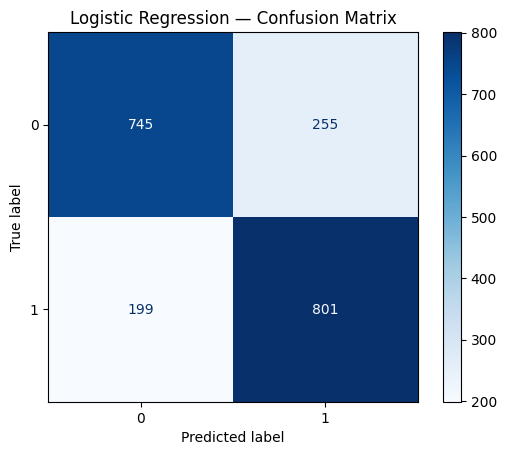

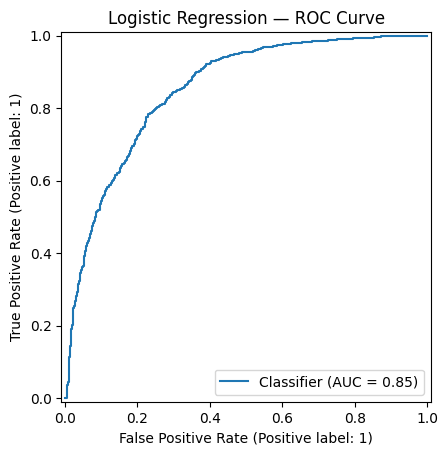


 Random Forest Results:
              precision    recall  f1-score   support

           0      0.837     0.848     0.843      1000
           1      0.846     0.835     0.840      1000

    accuracy                          0.842      2000
   macro avg      0.842     0.841     0.841      2000
weighted avg      0.842     0.842     0.841      2000



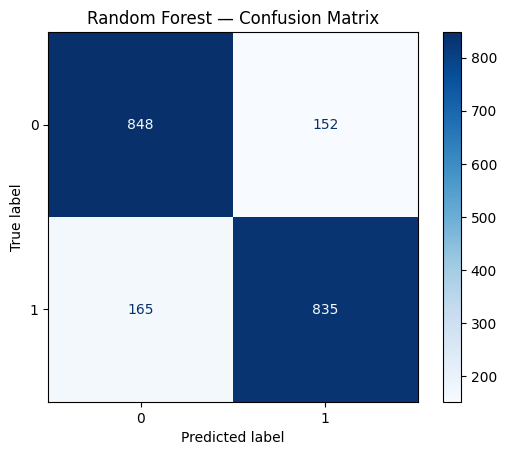

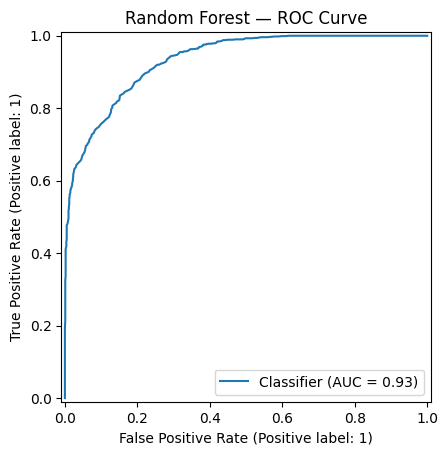

c:\Users\ajha26\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:16:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 XGBoost Results:
              precision    recall  f1-score   support

           0      0.860     0.846     0.853      1000
           1      0.848     0.862     0.855      1000

    accuracy                          0.854      2000
   macro avg      0.854     0.854     0.854      2000
weighted avg      0.854     0.854     0.854      2000



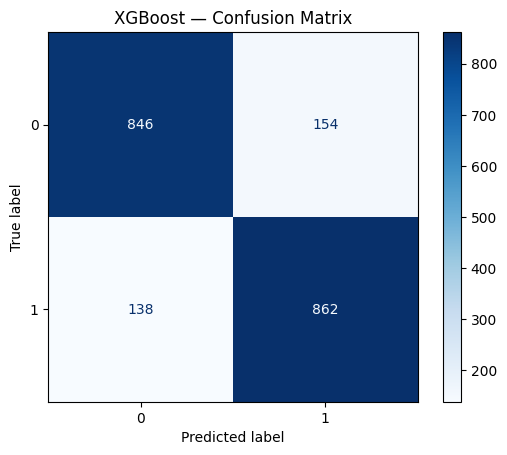

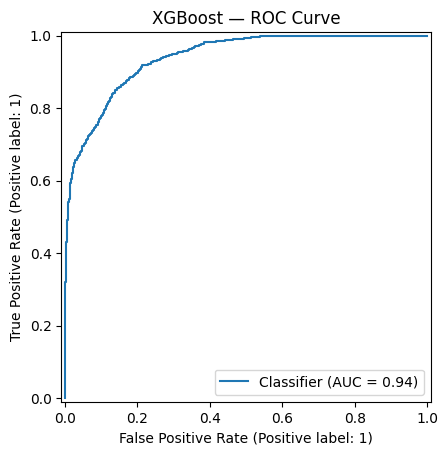


 SVM (RBF) Results:
              precision    recall  f1-score   support

           0      0.829     0.808     0.818      1000
           1      0.813     0.833     0.823      1000

    accuracy                          0.821      2000
   macro avg      0.821     0.821     0.820      2000
weighted avg      0.821     0.821     0.820      2000



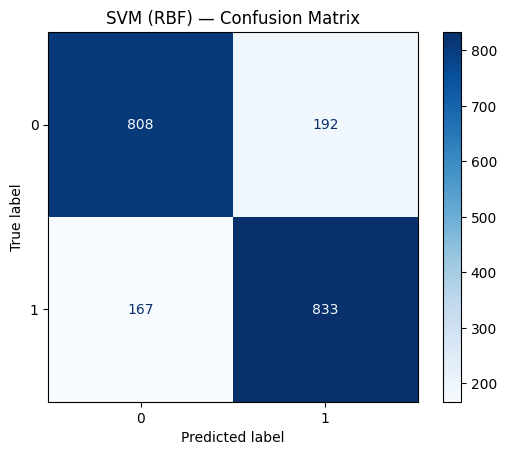

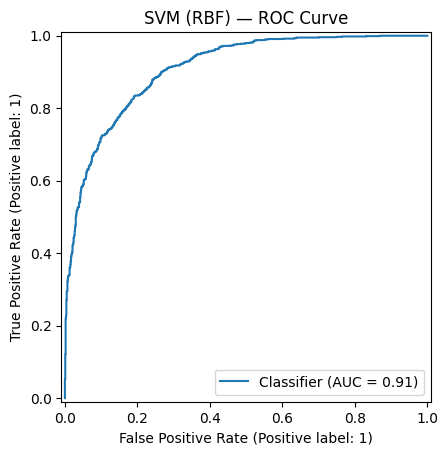

In [ ]:
# Training multiple models and comparing results

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

results = []

# 1 Logistic Regression
logreg = LogisticRegression(max_iter=2000, random_state=42)
results.append(evaluate_model(logreg, X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Regression"))

# 2️ Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
results.append(evaluate_model(rf, X_train, y_train, X_test, y_test, "Random Forest"))

# 3️ XGBoost
xgb = XGBClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)
results.append(evaluate_model(xgb, X_train, y_train, X_test, y_test, "XGBoost"))

# 4️ Support Vector Machine
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
results.append(evaluate_model(svm_model, X_train_scaled, y_train, X_test_scaled, y_test, "SVM (RBF)"))


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
XGBoost,0.854,0.848,0.862,0.855,0.940
Random Forest,0.842,0.846,0.835,0.840,0.933
SVM (RBF),0.820,0.813,0.833,0.823,0.908
Logistic Regression,0.773,0.759,0.801,0.779,0.851


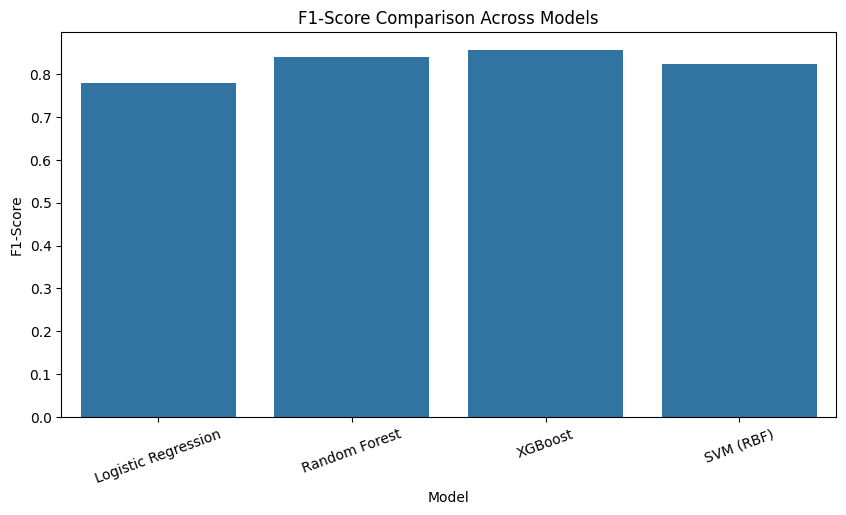

In [ ]:
# Step 8: Creating comparison table of all model metrics

results_df = pd.DataFrame(results).set_index("Model").round(3)
display(results_df.sort_values(by="F1-Score", ascending=False))

plt.figure(figsize=(10,5))
sns.barplot(x=results_df.index, y=results_df["F1-Score"])
plt.title("F1-Score Comparison Across Models")
plt.ylabel("F1-Score")
plt.xticks(rotation=20)
plt.show()


## Section 4: Hyperparameter Tuning for ML Models

Now performing grid or randomized search for each model to find the 
optimal hyperparameters using 5-fold cross-validation.

The best parameters found will be used to retrain each model 
and evaluate final performance on the test set.


In [10]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(" Grid and Randomized Search utilities ready.")


 Grid and Randomized Search utilities ready.


In [11]:
# Tuning Logistic Regression

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs", "saga"],
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid=param_grid_lr,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_

print(" Best Logistic Regression params:", grid_lr.best_params_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
 Best Logistic Regression params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [12]:
# Tuning Random Forest

param_dist_rf = {
    "n_estimators": randint(100, 400),
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": randint(2, 10),
    "max_features": ["sqrt", "log2"]
}

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=15,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_rf.fit(X_train, y_train)
best_rf = random_rf.best_estimator_

print(" Best Random Forest params:", random_rf.best_params_)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
 Best Random Forest params: {'max_depth': 30, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 370}


In [13]:
# Tuning XGBoost

param_dist_xgb = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
}

random_xgb = RandomizedSearchCV(
    XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    ),
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_xgb.fit(X_train, y_train)
best_xgb = random_xgb.best_estimator_

print("Best XGBoost params:", random_xgb.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\ajha26\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:19:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost params: {'colsample_bytree': np.float64(0.9140703845572055), 'learning_rate': np.float64(0.04993475643167195), 'max_depth': 9, 'n_estimators': 343, 'subsample': np.float64(0.836965827544817)}


In [14]:
# Tuning SVM (RBF Kernel)


param_grid_svm = {
    "C": [0.1, 1, 10, 50],
    "gamma": ["scale", 0.01, 0.001],
    "kernel": ["rbf"]
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid=param_grid_svm,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_scaled, y_train)
best_svm = grid_svm.best_estimator_

print("Best SVM params:", grid_svm.best_params_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best SVM params: {'C': 50, 'gamma': 0.01, 'kernel': 'rbf'}



 Logistic Regression (Tuned) Results:
              precision    recall  f1-score   support

           0      0.800     0.742     0.770      1000
           1      0.760     0.815     0.786      1000

    accuracy                          0.778      2000
   macro avg      0.780     0.778     0.778      2000
weighted avg      0.780     0.778     0.778      2000



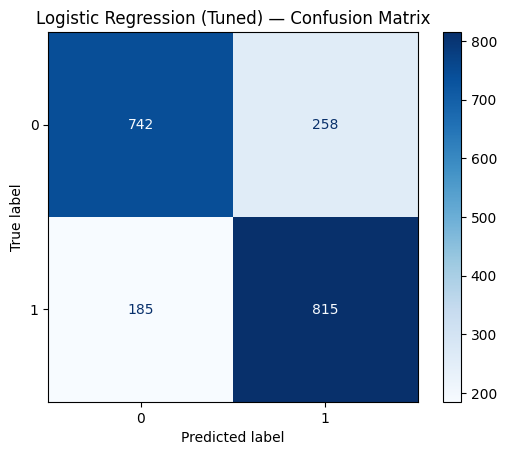

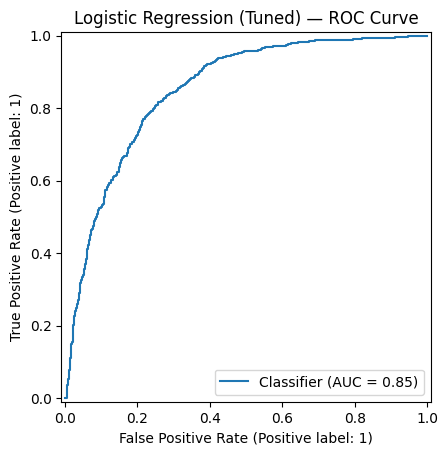


 Random Forest (Tuned) Results:
              precision    recall  f1-score   support

           0      0.839     0.841     0.840      1000
           1      0.841     0.839     0.840      1000

    accuracy                          0.840      2000
   macro avg      0.840     0.840     0.840      2000
weighted avg      0.840     0.840     0.840      2000



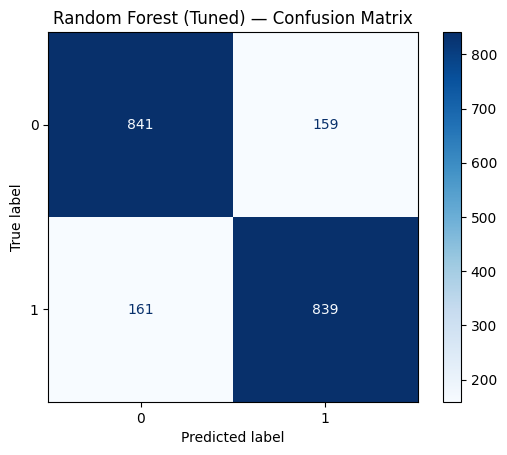

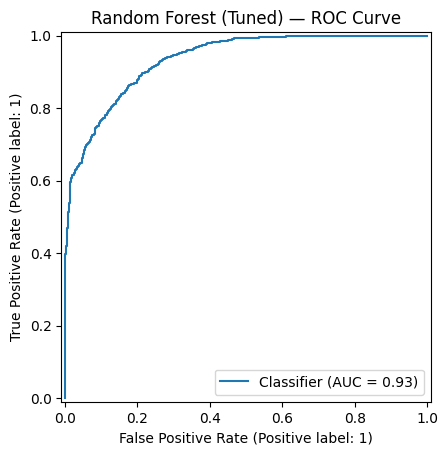

c:\Users\ajha26\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:20:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 XGBoost (Tuned) Results:
              precision    recall  f1-score   support

           0      0.848     0.841     0.844      1000
           1      0.842     0.849     0.846      1000

    accuracy                          0.845      2000
   macro avg      0.845     0.845     0.845      2000
weighted avg      0.845     0.845     0.845      2000



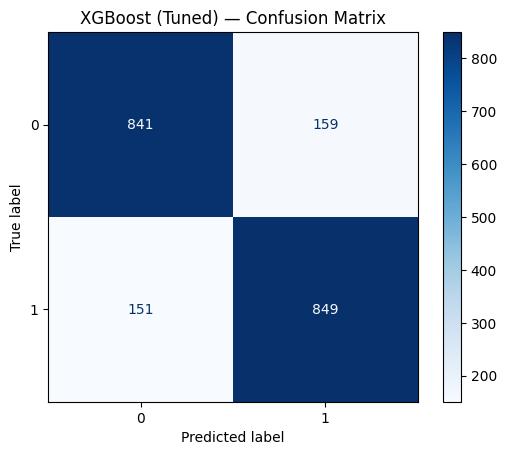

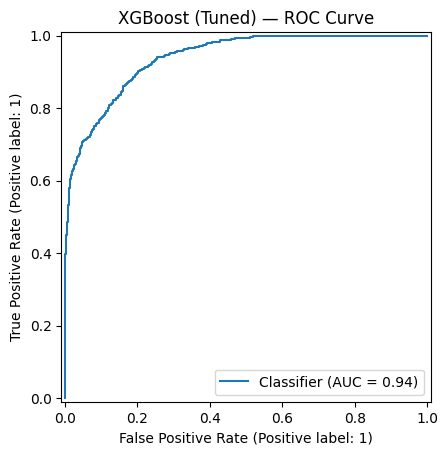


 SVM (Tuned) Results:
              precision    recall  f1-score   support

           0      0.840     0.822     0.831      1000
           1      0.826     0.843     0.834      1000

    accuracy                          0.833      2000
   macro avg      0.833     0.833     0.832      2000
weighted avg      0.833     0.833     0.832      2000



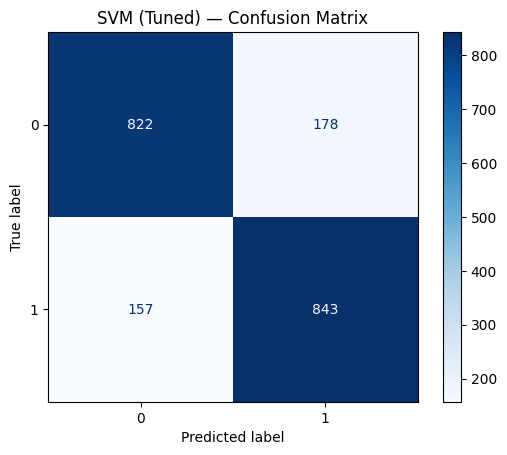

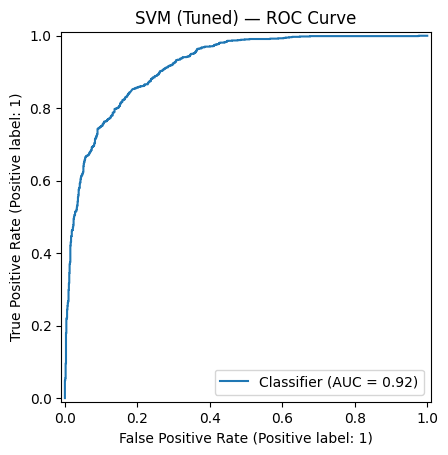

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
XGBoost (Tuned),0.845,0.842,0.849,0.846,0.939
Random Forest (Tuned),0.840,0.841,0.839,0.840,0.934
SVM (Tuned),0.832,0.826,0.843,0.834,0.918
Logistic Regression (Tuned),0.778,0.760,0.815,0.786,0.851


In [15]:
# Evaluating tuned models on test set


tuned_results = []

tuned_results.append(evaluate_model(best_lr, X_train_scaled, y_train, X_test_scaled, y_test, "Logistic Regression (Tuned)"))
tuned_results.append(evaluate_model(best_rf, X_train, y_train, X_test, y_test, "Random Forest (Tuned)"))
tuned_results.append(evaluate_model(best_xgb, X_train, y_train, X_test, y_test, "XGBoost (Tuned)"))
tuned_results.append(evaluate_model(best_svm, X_train_scaled, y_train, X_test_scaled, y_test, "SVM (Tuned)"))

tuned_results_df = pd.DataFrame(tuned_results).set_index("Model").round(3)
display(tuned_results_df.sort_values(by="F1-Score", ascending=False))


In [16]:
# Saving the tuned models for reuse

import joblib
save_dir = r"C:\Users\ajha26\Desktop\IS\models"

import os
os.makedirs(save_dir, exist_ok=True)

joblib.dump(best_lr, os.path.join(save_dir, "LogReg_Tuned.pkl"))
joblib.dump(best_rf, os.path.join(save_dir, "RF_Tuned.pkl"))
joblib.dump(best_xgb, os.path.join(save_dir, "XGB_Tuned.pkl"))
joblib.dump(best_svm, os.path.join(save_dir, "SVM_Tuned.pkl"))

print("All tuned models saved successfully!")


All tuned models saved successfully!


## Section 6: Final Model Performance Summary

Now that we’ve tuned and saved all models, 
we’ll consolidate their evaluation metrics into a single summary table 
and visualize the comparison across models.


 Final Model Evaluation Summary:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
XGBoost (Tuned),0.845,0.842,0.849,0.846,0.939
Random Forest (Tuned),0.840,0.841,0.839,0.840,0.934
SVM (Tuned),0.832,0.826,0.843,0.834,0.918
Logistic Regression (Tuned),0.778,0.760,0.815,0.786,0.851


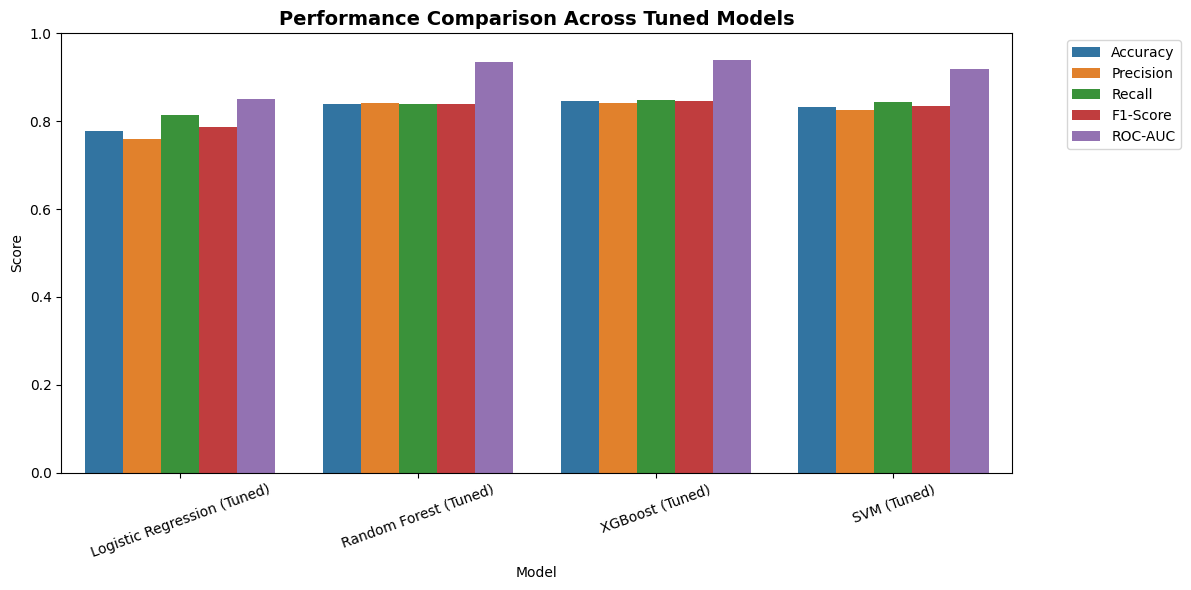

In [17]:
# Creating final summary table for all tuned models

tuned_results_df = pd.DataFrame(tuned_results).set_index("Model").round(3)

print(" Final Model Evaluation Summary:")
display(tuned_results_df.sort_values(by="F1-Score", ascending=False))

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

plt.figure(figsize=(12,6))
tuned_results_melted = tuned_results_df.reset_index().melt(
    id_vars="Model", value_vars=metrics_to_plot, var_name="Metric", value_name="Score"
)

sns.barplot(data=tuned_results_melted, x="Model", y="Score", hue="Metric")
plt.title("Performance Comparison Across Tuned Models", fontsize=14, weight="bold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [18]:
# Saving summary results to Excel
import os

save_dir = r"C:\Users\ajha26\Desktop\IS\Results"
os.makedirs(save_dir, exist_ok=True)

results_path = os.path.join(save_dir, "Model_Performance_Summary.xlsx")
tuned_results_df.to_excel(results_path)

print(f"Results summary saved to: {results_path}")


Results summary saved to: C:\Users\ajha26\Desktop\IS\Results\Model_Performance_Summary.xlsx


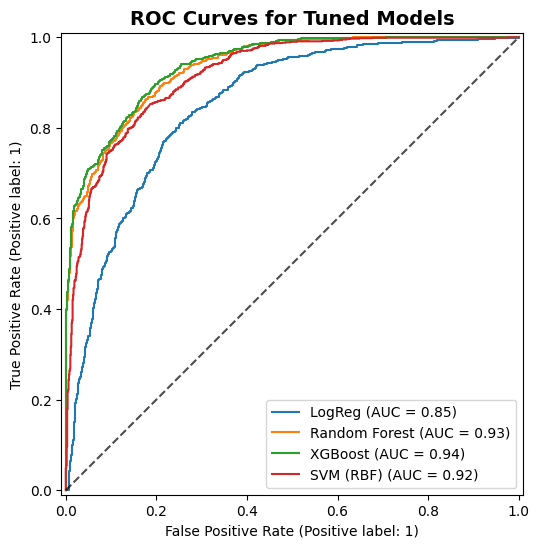

In [19]:
# Combined ROC Curve Plot for All Models


plt.figure(figsize=(8,6))
for model, name, Xtr, Xts in [
    (best_lr, "LogReg", X_train_scaled, X_test_scaled),
    (best_rf, "Random Forest", X_train, X_test),
    (best_xgb, "XGBoost", X_train, X_test),
    (best_svm, "SVM (RBF)", X_train_scaled, X_test_scaled)
]:
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(Xts)[:, 1]
    else:
        y_proba = model.decision_function(Xts)
    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=plt.gca())

plt.title("ROC Curves for Tuned Models", fontsize=14, weight="bold")
plt.plot([0,1],[0,1],'k--',alpha=0.7)
plt.legend()
plt.show()


# Section 7: Model Interpretability & Feature Importance Analysis

Understanding **why** the models classify a text as AI-generated or human-written 
is critical for transparency and trust in AI detection.

This section will interpret the trained models using multiple approaches:

1. **Feature Importance (Global Level)**  
   - Tree-based models (Random Forest, XGBoost)  
   - Coefficients (Logistic Regression)

2. **Explainability with SHAP (Local + Global)**  
   - SHAP summary plots (overall feature impact)
   - SHAP dependence plots (feature interactions)
   - Individual explanations (sample predictions)

3. **Partial Dependence (PDP) & Interaction Plots**  
   - Show how changing one feature affects model output  
   - Visualize feature interactions (for top 2 features)


In [ ]:
import shap
from sklearn.inspection import PartialDependenceDisplay

# Ensuring SHAP visualizations render correctly in Jupyter
shap.initjs()

# Focusing primarily on:
# - Random Forest (best_rf)
# - XGBoost (best_xgb)
# - Logistic Regression (best_lr)
# SVM is less interpretable (kernel-based), so skipping deep SHAP there.

print("Interpretability libraries loaded and ready.")


Interpretability libraries loaded and ready.


## 7.1 Global Feature Importance

First looking at the **global feature importance** : 
which features had the largest average impact across all predictions.

For:
- **Random Forest / XGBoost:** using built-in `feature_importances_`
- **Logistic Regression:** using model coefficients (`coef_`)


C:\Users\ajha26\AppData\Local\Temp\ipykernel_14864\1871926003.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


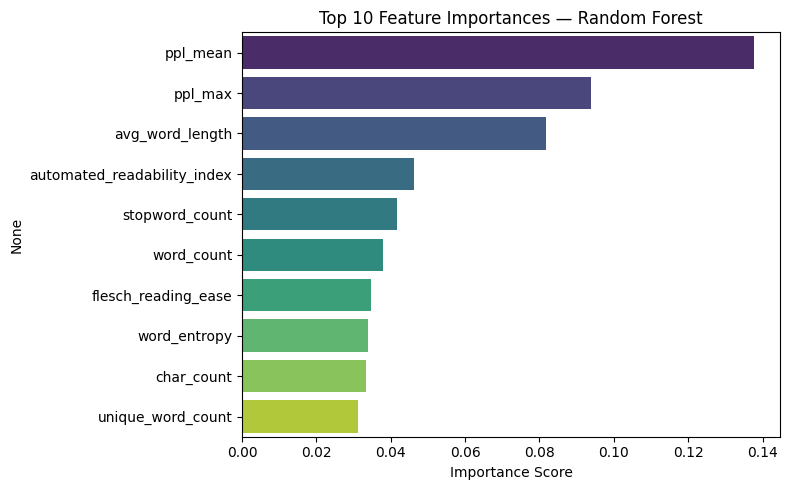

C:\Users\ajha26\AppData\Local\Temp\ipykernel_14864\1871926003.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


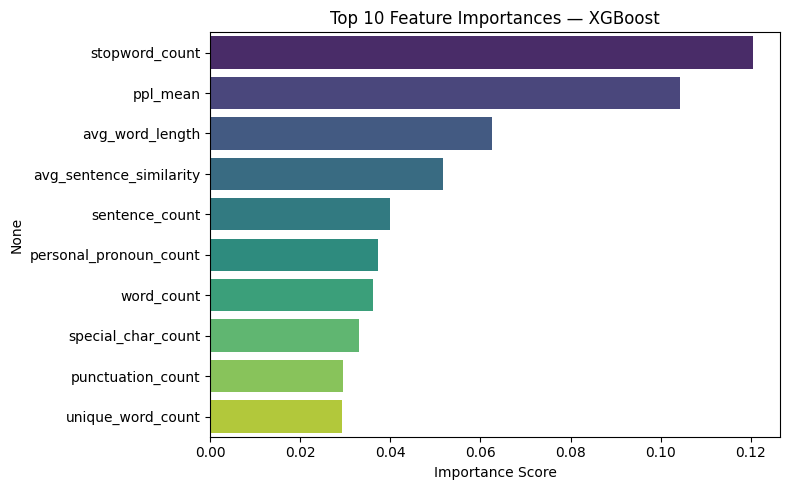

In [21]:
# Tree-based feature importances


def plot_feature_importance(model, feature_names, model_name, top_n=10):
    """Plot top N most important features."""
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)[:top_n]
    
    plt.figure(figsize=(8,5))
    sns.barplot(x=importances.values, y=importances.index, palette="viridis")
    plt.title(f"Top {top_n} Feature Importances — {model_name}")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()
    return importances

# Plots for Random Forest and XGBoost
rf_importances = plot_feature_importance(best_rf, X.columns, "Random Forest")
xgb_importances = plot_feature_importance(best_xgb, X.columns, "XGBoost")


C:\Users\ajha26\AppData\Local\Temp\ipykernel_14864\2011455631.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef_importances.values, y=coef_importances.index, palette="coolwarm")


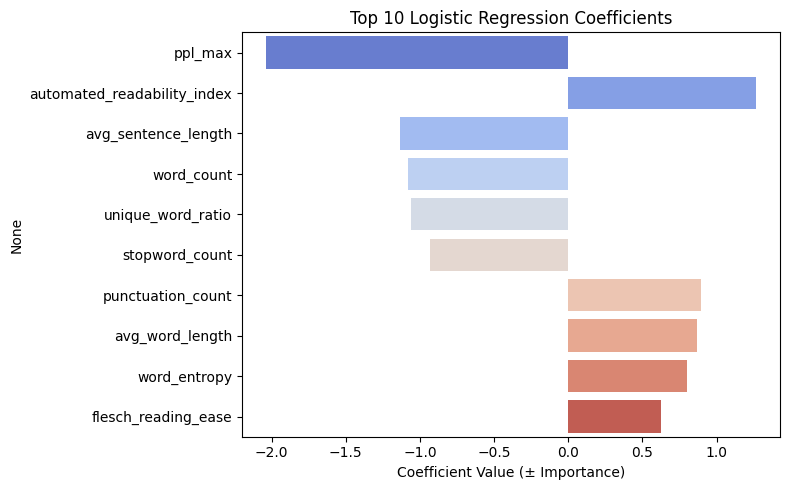

ppl_max                       -2.034783
automated_readability_index    1.262079
avg_sentence_length           -1.131825
word_count                    -1.082645
unique_word_ratio             -1.060289
stopword_count                -0.930536
punctuation_count              0.892588
avg_word_length                0.865070
word_entropy                   0.800264
flesch_reading_ease            0.624914
dtype: float64

In [22]:
# Logistic Regression Coefficient Importance

coef_importances = pd.Series(
    best_lr.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)[:10]

plt.figure(figsize=(8,5))
sns.barplot(x=coef_importances.values, y=coef_importances.index, palette="coolwarm")
plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value (± Importance)")
plt.tight_layout()
plt.show()

coef_importances


## 7.2 SHAP Value Explanations

SHAP (SHapley Additive exPlanations) helps us understand:
- **Global importance** : which features consistently influence predictions
- **Local explanations** : why a specific text was classified as AI or Human

We’ll compute SHAP values for:
- Random Forest  
- XGBoost  
- Logistic Regression  
and visualize them via summary and dependence plots.


In [24]:
import shap
shap.__version__


'0.50.0'


==== SHAP Analysis Starting ====

Running SHAP for Random Forest...
RF SHAP computed. Shape: (2000, 36, 2)


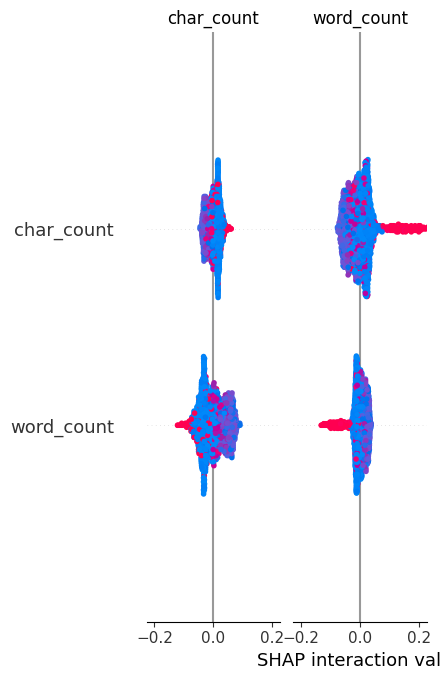

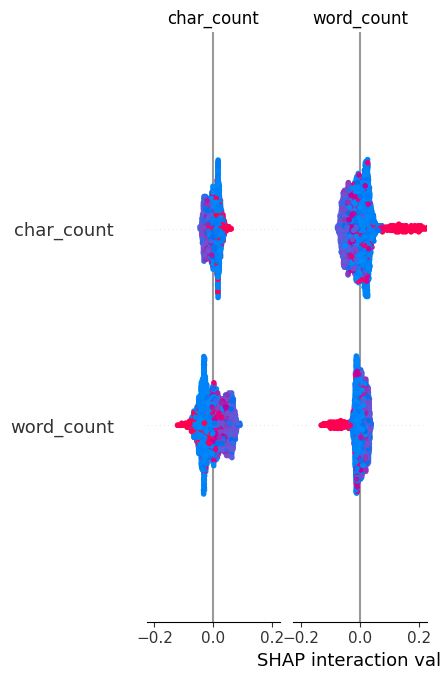

✔ Random Forest SHAP plots completed.

Running SHAP for XGBoost...
XGBoost SHAP computed. Shape: (2000, 36)


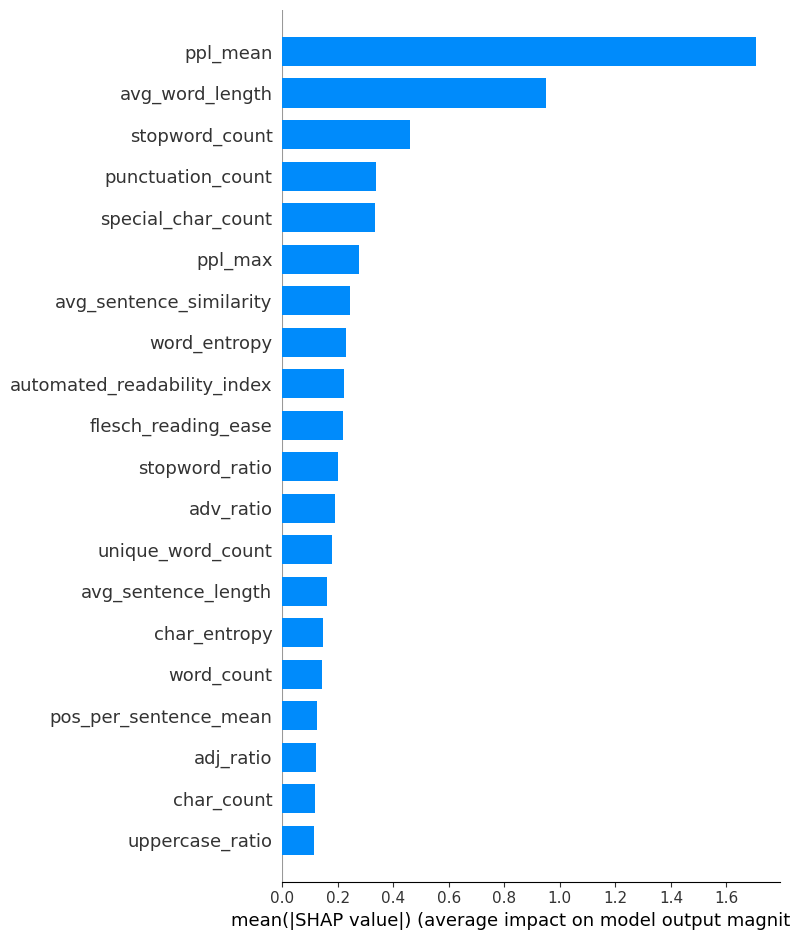

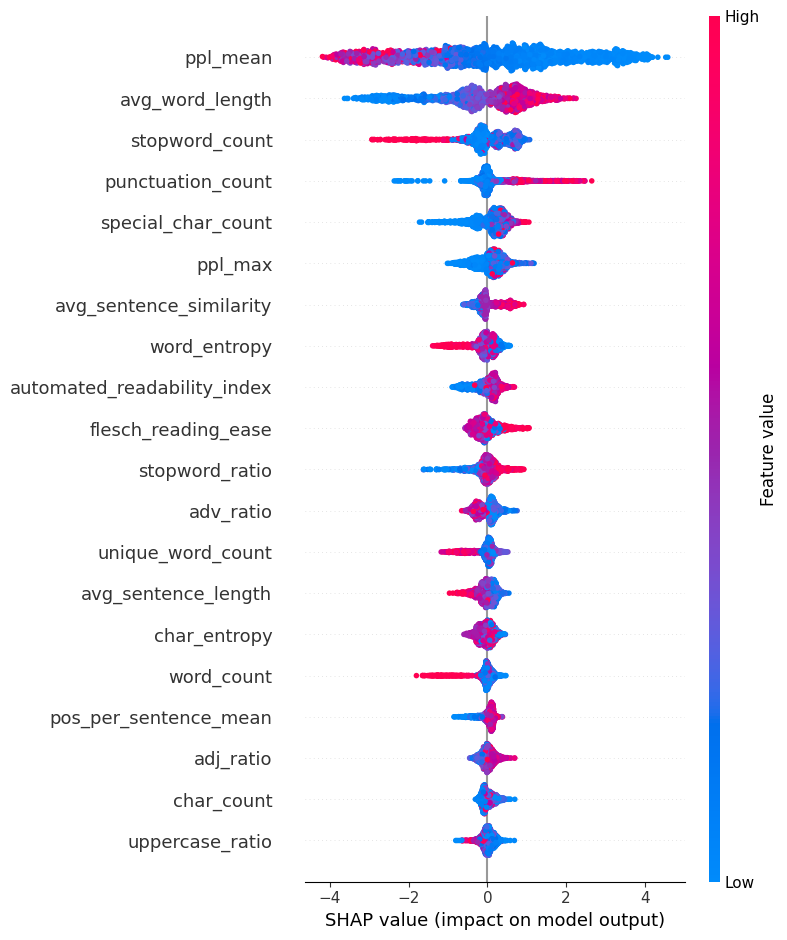

✔ XGBoost SHAP plots completed.

Running SHAP for Logistic Regression (LinearExplainer)...
LR SHAP computed. Shape: (2000, 36)


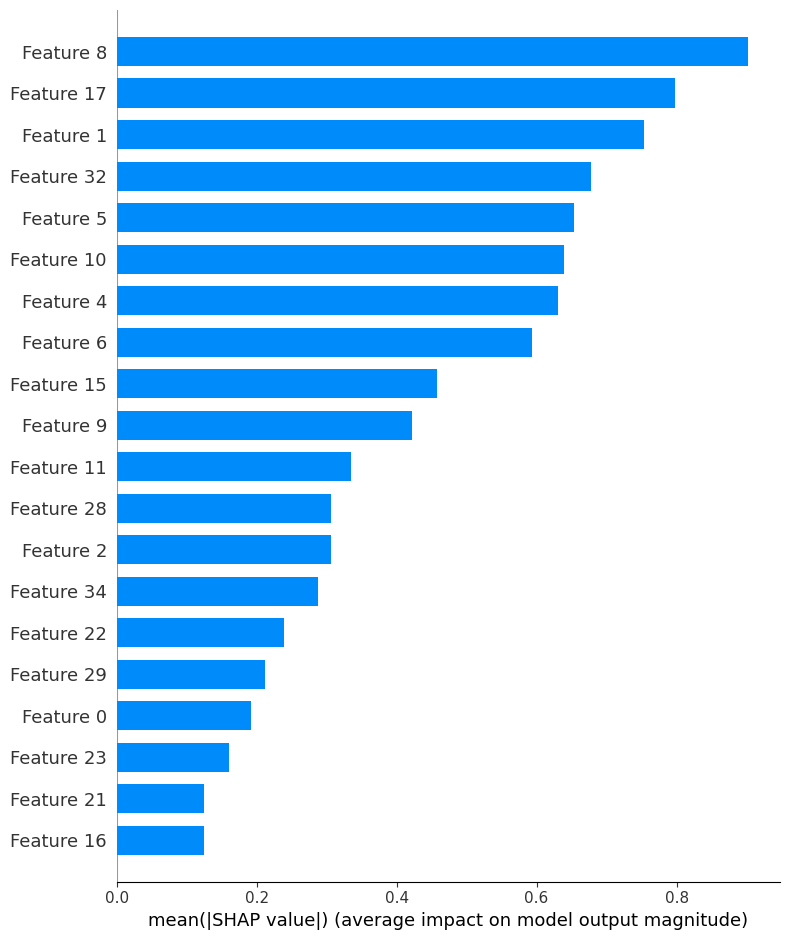

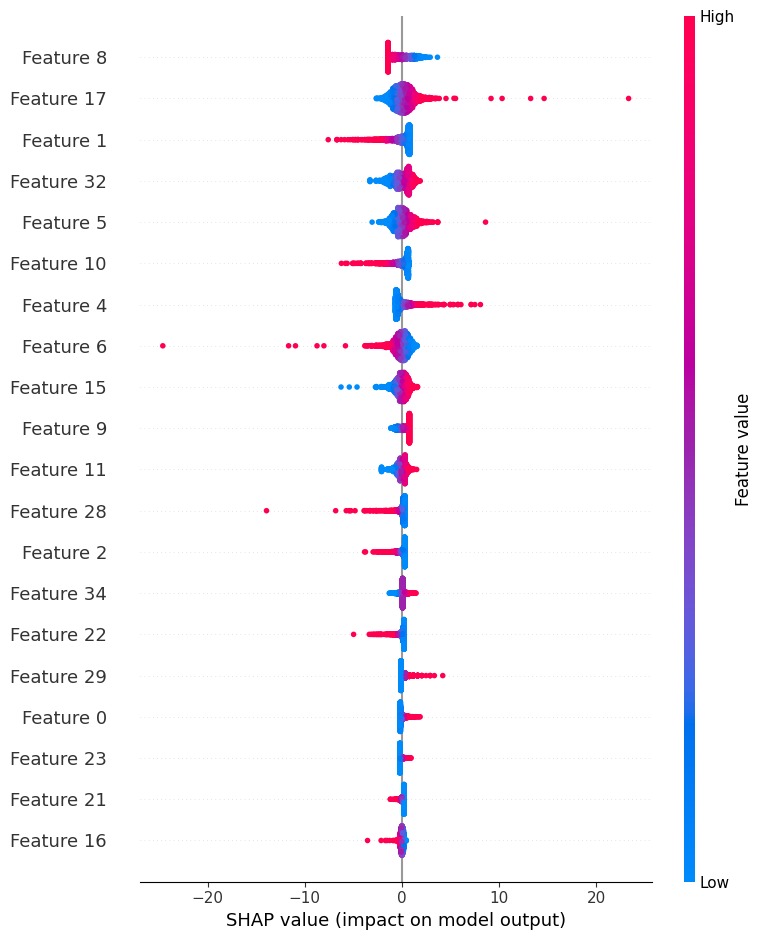

✔ Logistic Regression SHAP plots completed.


==== All SHAP Analysis Completed Successfully ====



In [ ]:
# SHAP for Tree Models + LinearExplainer for Logistic Regression

import shap

print("\n==== SHAP Analysis Starting ====\n")


# 1. Random Forest — TreeExplainer

print("Running SHAP for Random Forest...")

explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf(X_test)


if hasattr(shap_values_rf, "values"):
    shap_rf = shap_values_rf.values
else:
    shap_rf = shap_values_rf[1] if isinstance(shap_values_rf, list) else shap_values_rf

print("RF SHAP computed. Shape:", shap_rf.shape)

shap.summary_plot(shap_rf, X_test, plot_type="bar", show=True)
shap.summary_plot(shap_rf, X_test, show=True)

print("Random Forest SHAP plots completed.\n")



# 2. XGBoost — TreeExplainer

print("Running SHAP for XGBoost...")

explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb(X_test)

if hasattr(shap_values_xgb, "values"):
    shap_xgb = shap_values_xgb.values
else:
    shap_xgb = shap_values_xgb[1] if isinstance(shap_values_xgb, list) else shap_values_xgb

print("XGBoost SHAP computed. Shape:", shap_xgb.shape)

shap.summary_plot(shap_xgb, X_test, plot_type="bar", show=True)
shap.summary_plot(shap_xgb, X_test, show=True)

print("XGBoost SHAP plots completed.\n")



# 3. Logistic Regression — LinearExplainer (FAST)

print("Running SHAP for Logistic Regression (LinearExplainer)...")

explainer_lr = shap.LinearExplainer(best_lr, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_scaled)


shap_lr = shap_values_lr

print("LR SHAP computed. Shape:", shap_lr.shape)


shap.summary_plot(shap_lr, X_test_scaled, plot_type="bar", show=True)
shap.summary_plot(shap_lr, X_test_scaled, show=True)

print("Logistic Regression SHAP plots completed.\n")

print("\n==== All SHAP Analysis Completed Successfully ====\n")


=== SHAP VISUALIZATION STARTED ===


=== SHAP: Random Forest Summary Bar ===


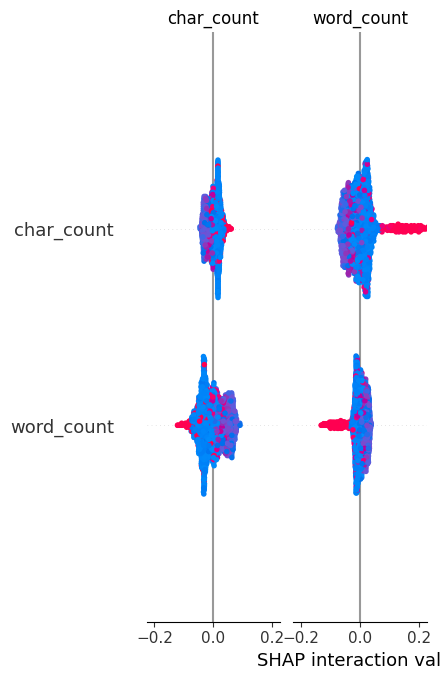


=== SHAP: Random Forest Beeswarm ===


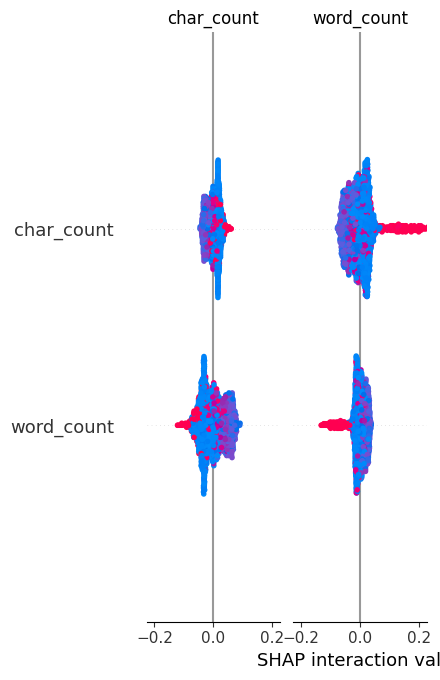


=== SHAP: XGBoost Summary Bar ===


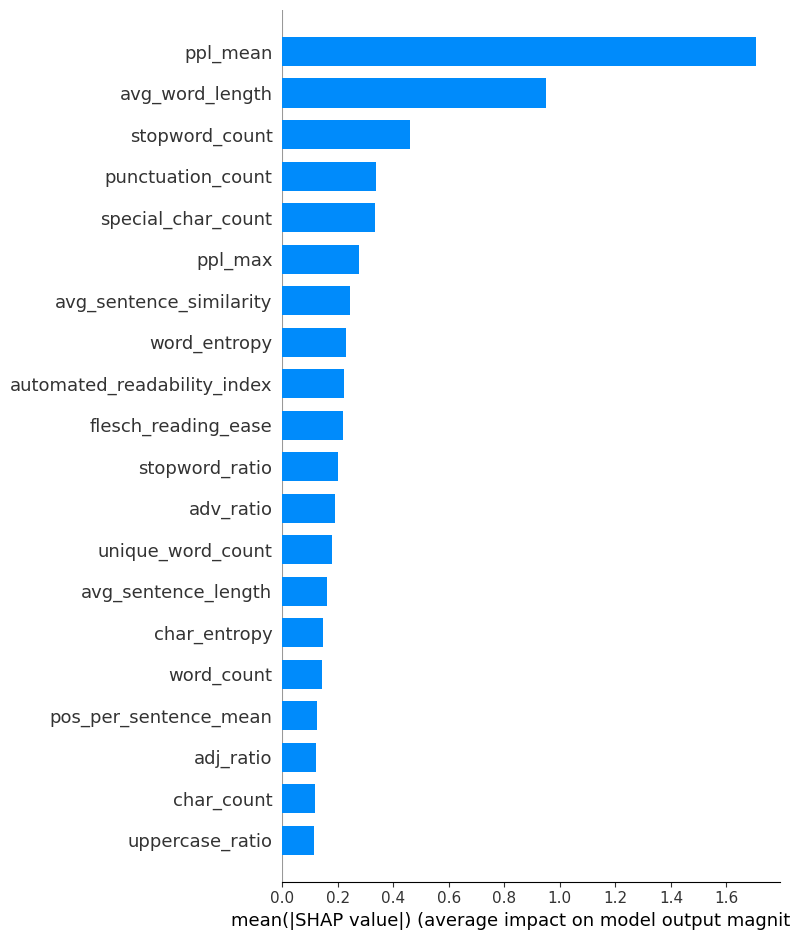


=== SHAP: XGBoost Beeswarm ===


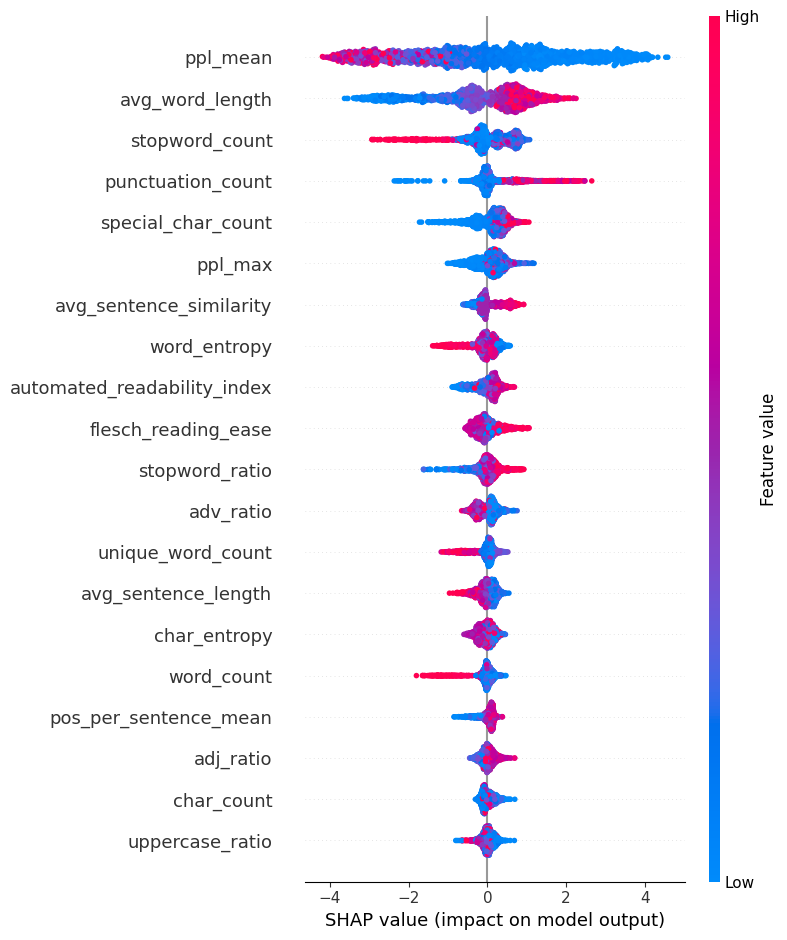


=== SHAP: XGBoost Interaction Summary ===


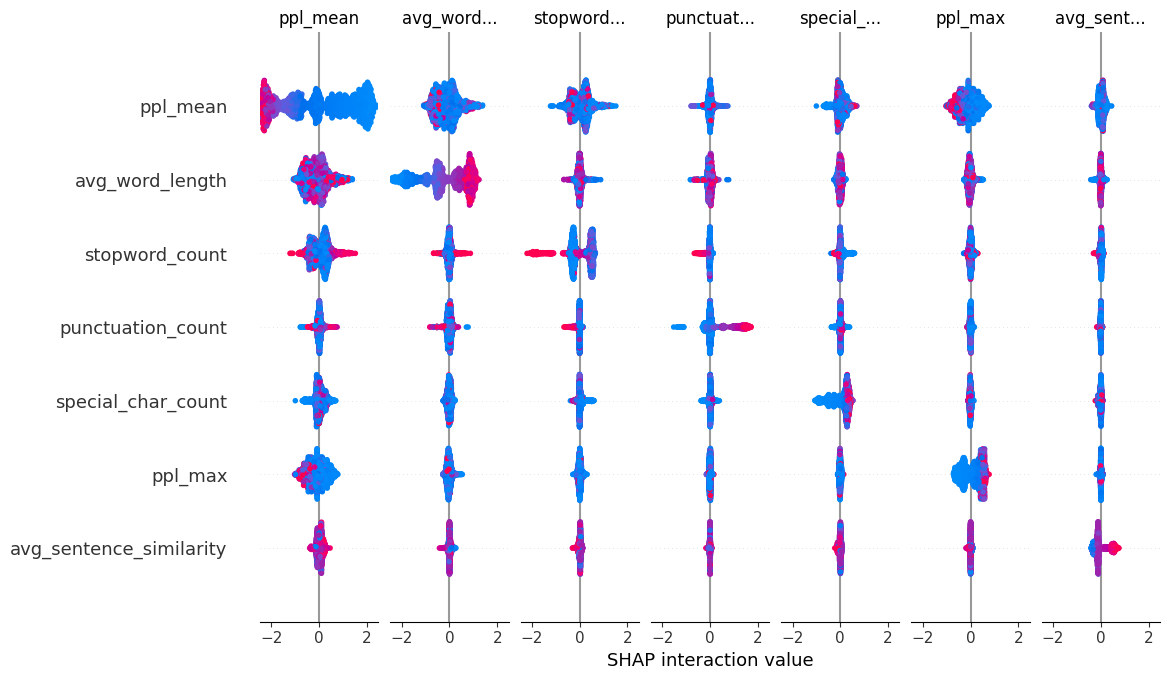


=== SHAP: XGBoost Dependence Plots ===
Dependence plot for: stopword_count


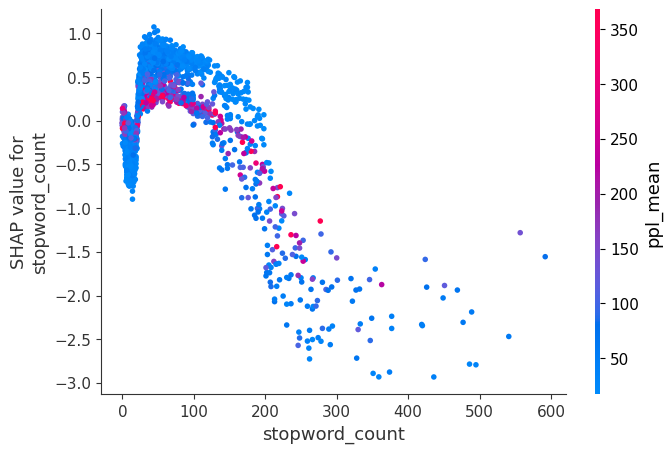

Dependence plot for: ppl_mean


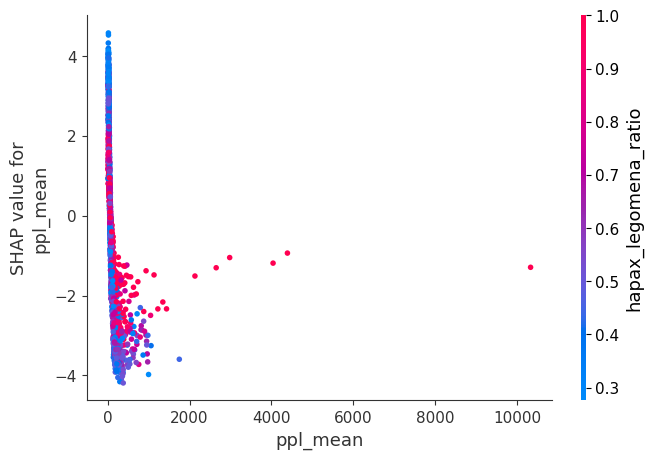

Dependence plot for: avg_word_length


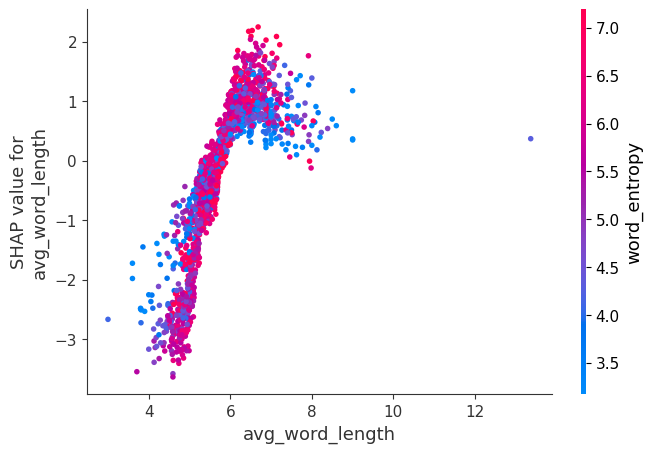


=== SHAP: Logistic Regression Summary Bar ===


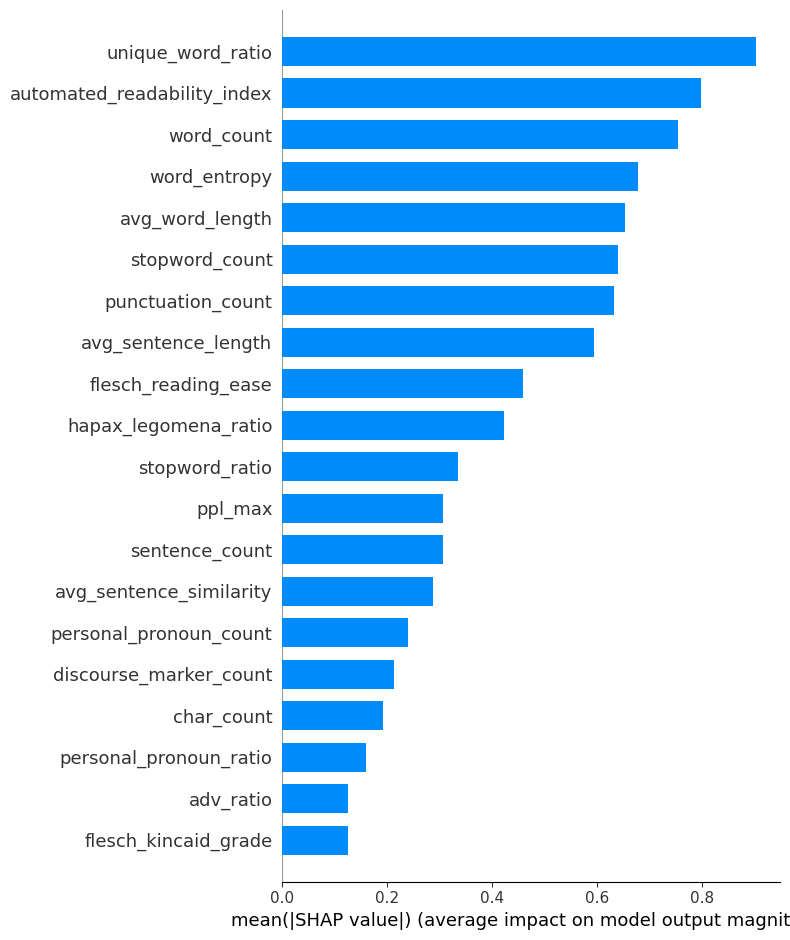


=== SHAP: Logistic Regression Beeswarm ===


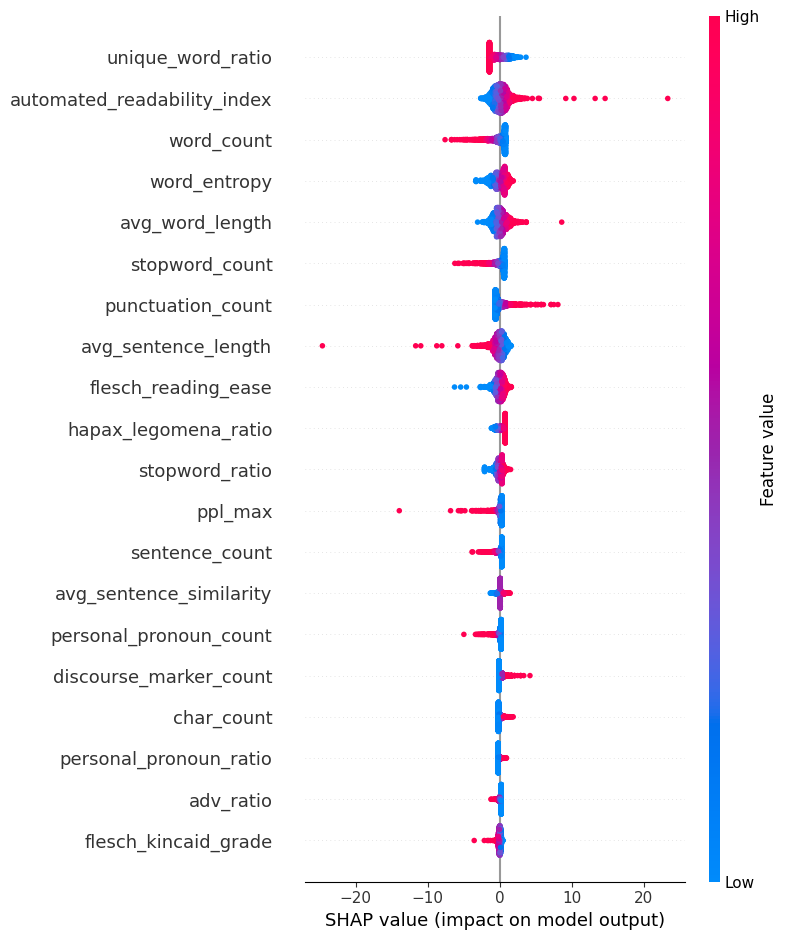


=== SHAP VISUALIZATION COMPLETE ===


In [ ]:
print("=== SHAP VISUALIZATION STARTED ===\n")

# 1. RANDOM FOREST 

print("\n=== SHAP: Random Forest Summary Bar ===")
shap.summary_plot(
    shap_values_rf.values,
    X_test,
    plot_type="bar",
    show=True
)

print("\n=== SHAP: Random Forest Beeswarm ===")
shap.summary_plot(
    shap_values_rf.values,
    X_test,
    show=True
)



# 2. XGBOOST 

print("\n=== SHAP: XGBoost Summary Bar ===")
shap.summary_plot(
    shap_values_xgb.values,
    X_test,
    plot_type="bar",
    show=True
)

print("\n=== SHAP: XGBoost Beeswarm ===")
shap.summary_plot(
    shap_values_xgb.values,
    X_test,
    show=True
)

# Interaction summary
print("\n=== SHAP: XGBoost Interaction Summary ===")
xgb_interaction = shap.TreeExplainer(best_xgb).shap_interaction_values(X_test)
shap.summary_plot(xgb_interaction, X_test, show=True)

# Dependence plots (XGB only)
print("\n=== SHAP: XGBoost Dependence Plots ===")
top_feats_xgb = xgb_importances.index[:3]

for feat in top_feats_xgb:
    print(f"Dependence plot for: {feat}")
    shap.dependence_plot(
        feat,
        shap_values_xgb.values,
        X_test,
        show=True
    )


# 3. LOGISTIC REGRESSION — LinearExplainer

print("\n=== SHAP: Logistic Regression Summary Bar ===")
shap.summary_plot(
    shap_values_lr,
    X_test_scaled,
    plot_type="bar",
    feature_names=X.columns,
    show=True
)

print("\n=== SHAP: Logistic Regression Beeswarm ===")
shap.summary_plot(
    shap_values_lr,
    X_test_scaled,
    feature_names=X.columns,
    show=True
)


print("\n=== SHAP VISUALIZATION COMPLETE ===")


## 7.3 Partial Dependence and Feature Interaction Plots

Partial Dependence (PDP) plots show how changing one or two features 
affects the model’s predicted probability of "AI-written".

This provides intuitive, global interpretability.


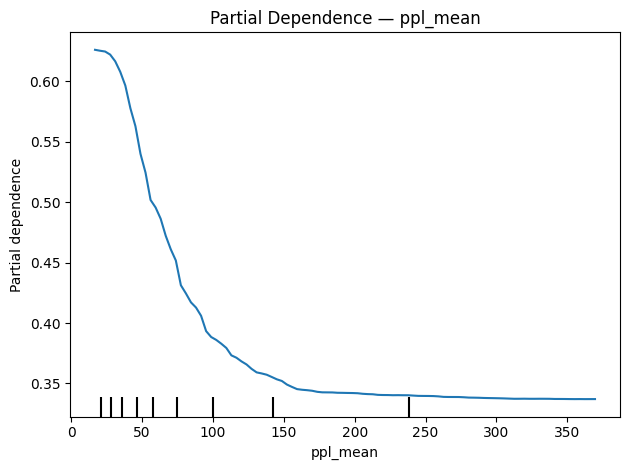

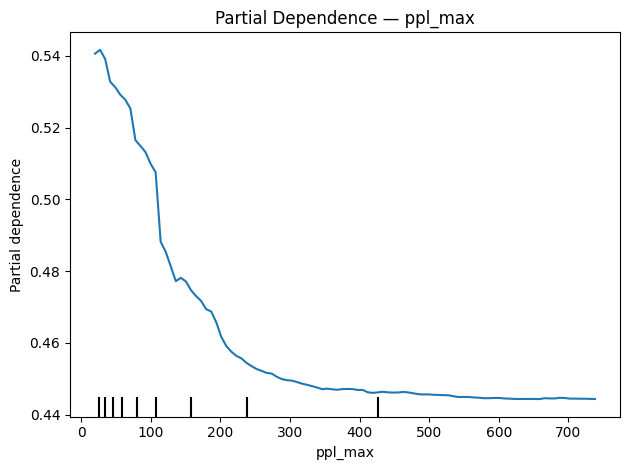

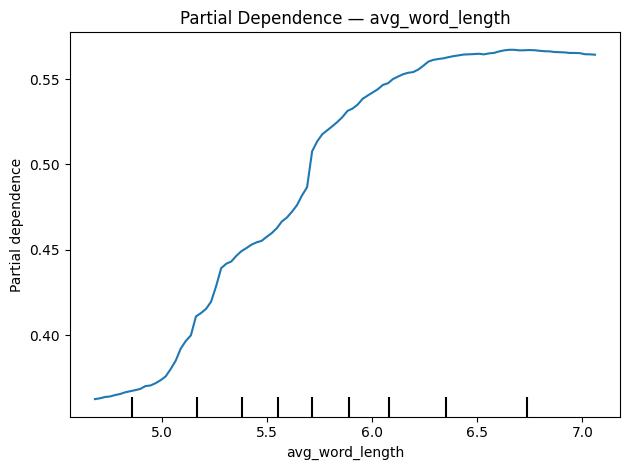

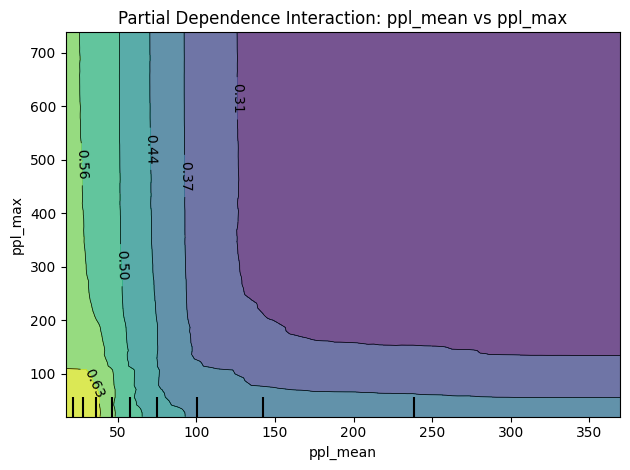

In [38]:
#   Partial Dependence Plots


# Top features from Random Forest
top_features = rf_importances.index[:3]

# Single-feature PDPs
for feat in top_features:
    PartialDependenceDisplay.from_estimator(best_rf, X_test, [feat], kind="average")
    plt.title(f"Partial Dependence — {feat}")
    plt.tight_layout()
    plt.show()

# Interaction PDP (top 2 features)
PartialDependenceDisplay.from_estimator(best_rf, X_test, [(top_features[0], top_features[1])], kind="average")
plt.title(f"Partial Dependence Interaction: {top_features[0]} vs {top_features[1]}")
plt.tight_layout()
plt.show()



=== XGBoost PDP (Single Features) ===
Plotting PDP for XGBoost feature: stopword_count


c:\Users\ajha26\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 10 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


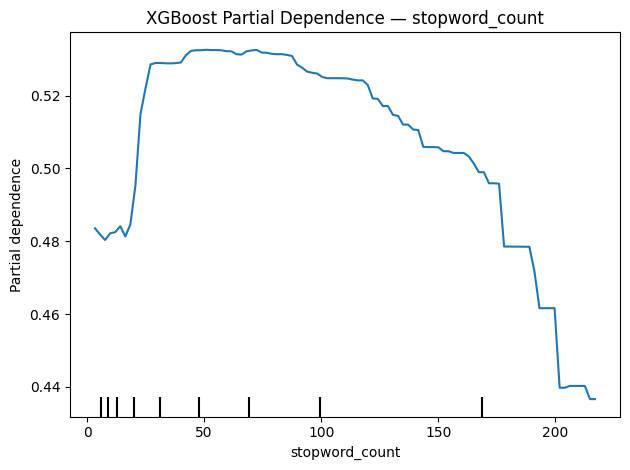

Plotting PDP for XGBoost feature: ppl_mean


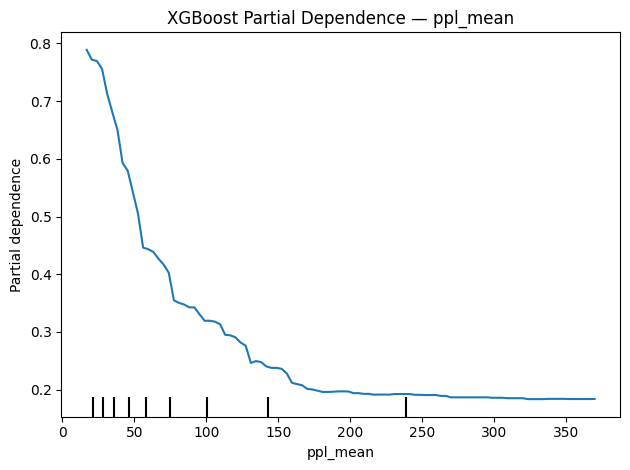

Plotting PDP for XGBoost feature: avg_word_length


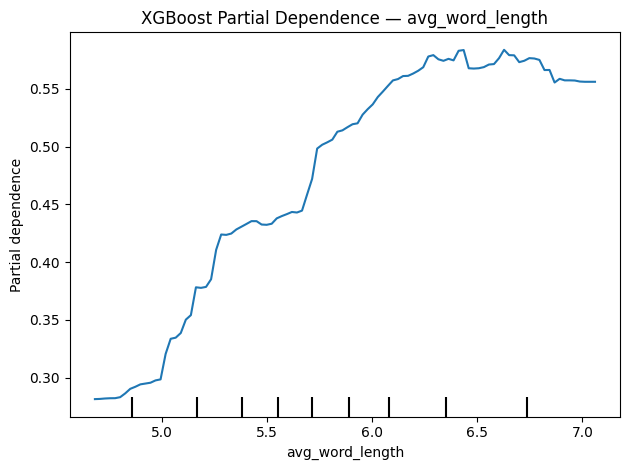

In [39]:
#  Partial Dependence Plots — XGBoost

print("\n=== XGBoost PDP (Single Features) ===")

top_features_xgb = xgb_importances.index[:3]  # top 3 features

for feat in top_features_xgb:
    print(f"Plotting PDP for XGBoost feature: {feat}")
    PartialDependenceDisplay.from_estimator(
        best_xgb,
        X_test,
        [feat],
        kind="average"
    )
    plt.title(f"XGBoost Partial Dependence — {feat}")
    plt.tight_layout()
    plt.show()


#  Section 8: Local Explanations: "Why Was This Text Classified as AI or Human?"

In this section, we move from **global interpretability** (which features matter overall) 
to **local interpretability** — explaining *why* a specific text 
was classified as AI-generated or human-written.

We’ll use **SHAP force plots** and **waterfall plots** to visualize 
feature contributions for individual predictions.


==================== TEXT SAMPLE ====================
Index: 5911
True Label: 1

TEXT:

Hey there!  So, you want me to write an essay about how awesome it is for individuals to make their own decisions?  Like, I'm totally down with that! 

So, let's get into it! Making decisions is like, super important for families and kids, you know?  It's like, when we make our own choices, we learn how to be responsible and stuff.  And trust me, responsibility is like, a big deal! 

First of all, when we make our own decisions, we learn how to be independent.  Like, we can do things on our own without relying on others.  And that's like, really cool, you know?  It's like, we can be our own bo ...



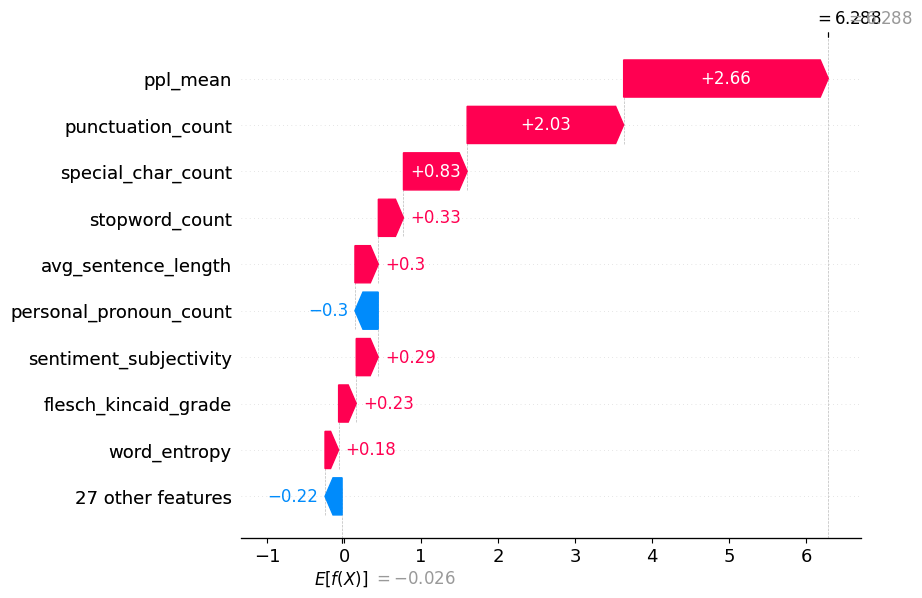

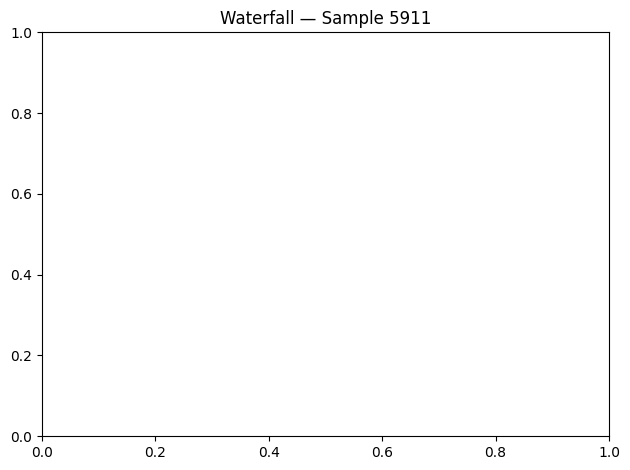

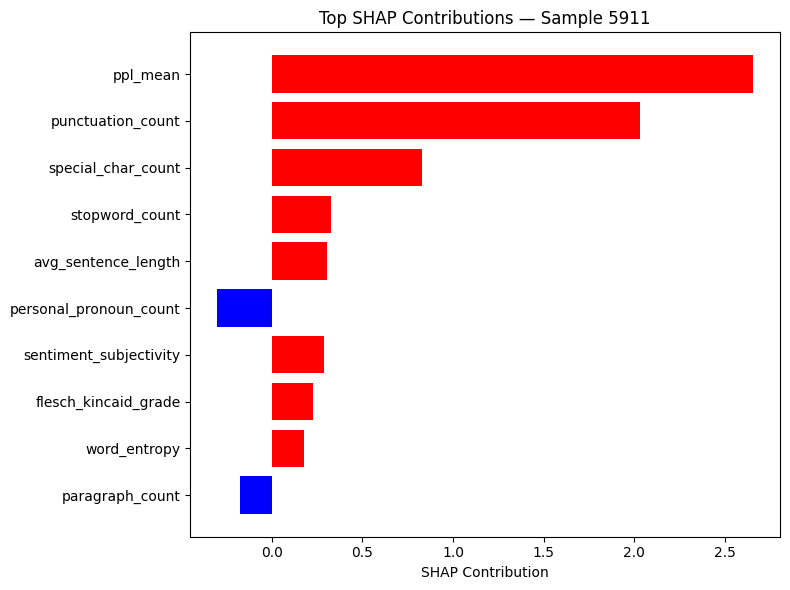


==================== TEXT SAMPLE ====================
Index: 2919
True Label: 0

TEXT:

Three new acts are being tipped for success in 2016 after being shortlisted for the Brits Critics' Choice Award. ...



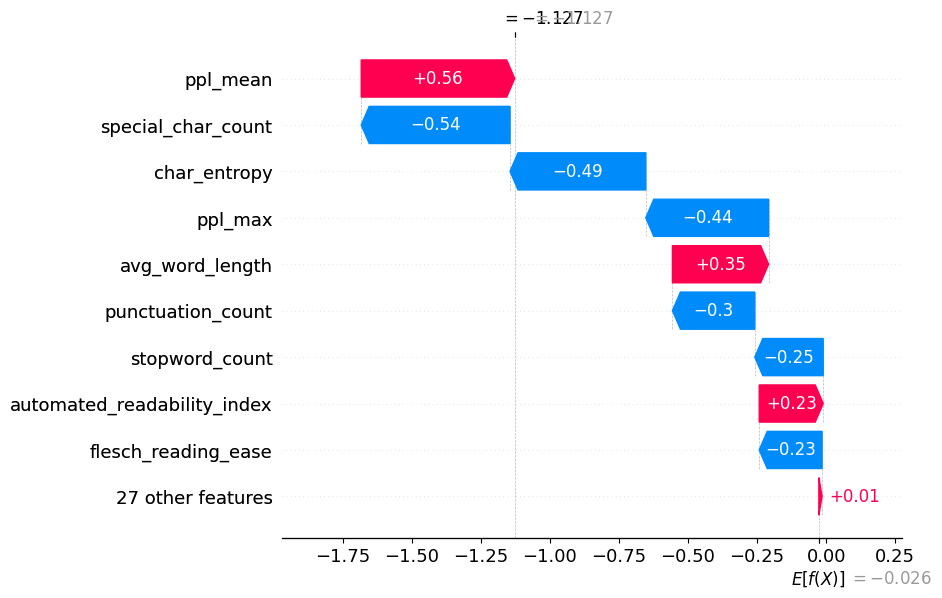

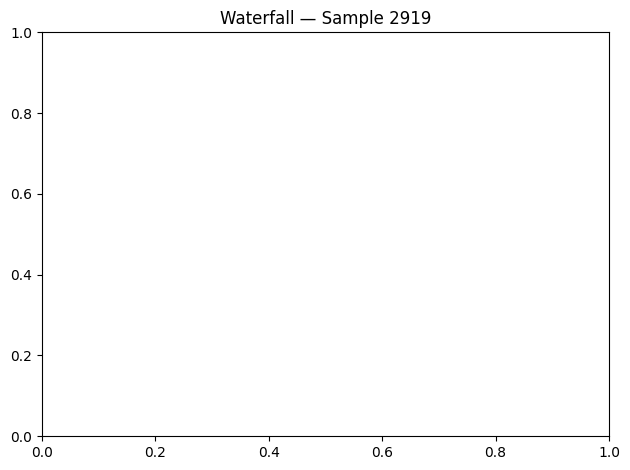

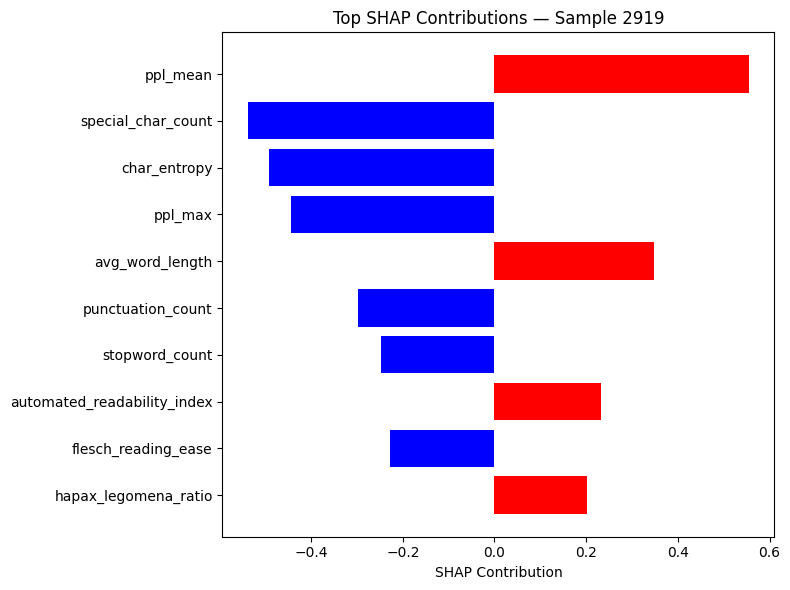


==================== TEXT SAMPLE ====================
Index: 9785
True Label: 1

TEXT:

As a little child, would you like to know how people in the past used pigeons to send messages? How do they make the pigeon understand where to go and deliver the message? ...



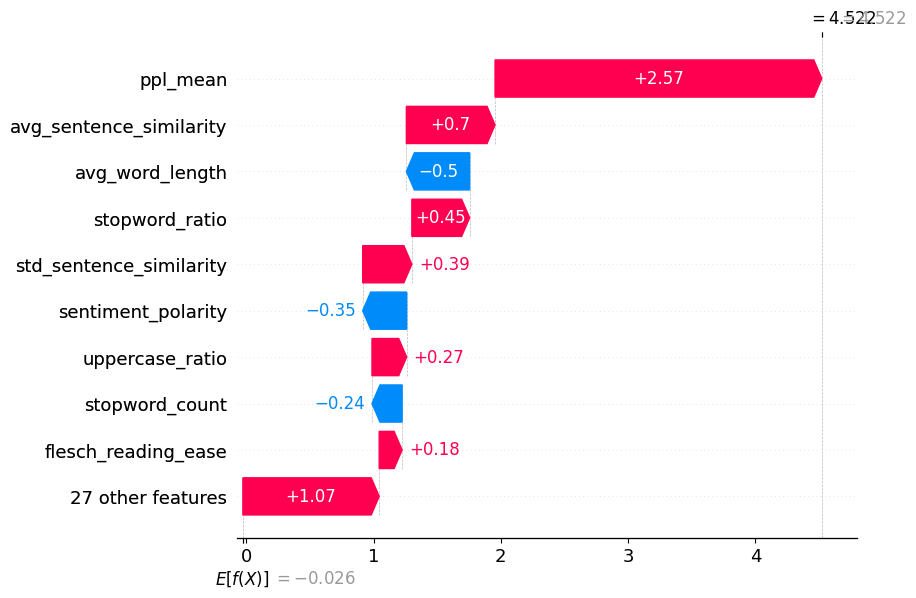

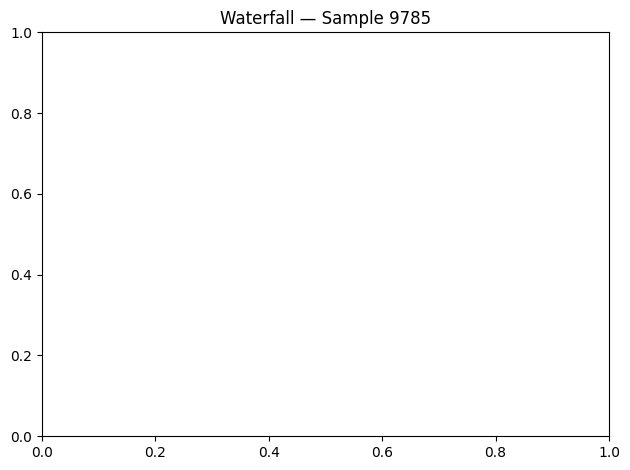

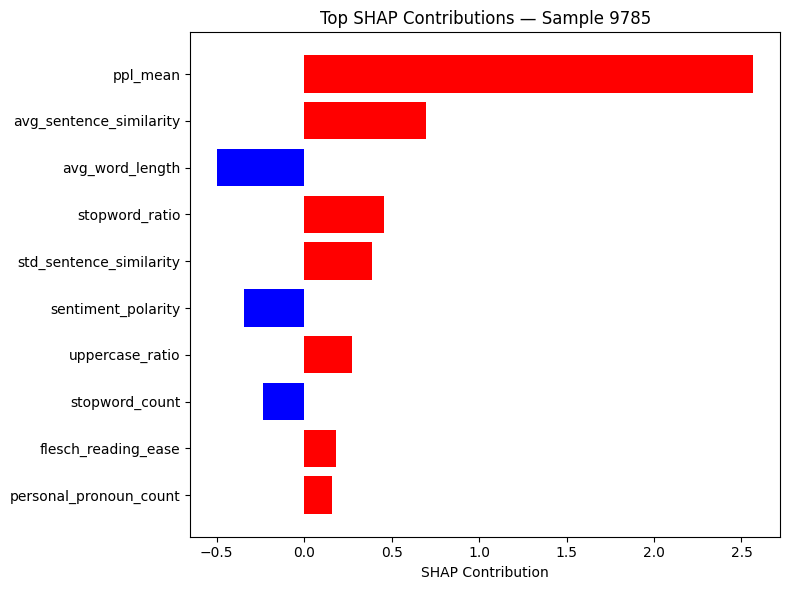


==================== TEXT SAMPLE ====================
Index: 55
True Label: 0

TEXT:

I am going @NUM1 write about a time when I was patient. My advocate @PERSON1 was soppese @NUM1 buy me some pens fo many of @DATE1 year as part of my @DATE1 money. I have been asking him everyday since then. â€œ@PERSON2, @CAPS1 @MONEY1 do ur daily shopping yetâ€?  â€œno.â€ â€œ@CAPS2.â€ @CAPS3 said â€œbecause I want my pens @CAPS4 @DATE1 present remember the @NUM3 owe meâ€. â€œ@CAPS5 I do but be patientâ€ â€œ@CAPS6 ok my patients is about @NUM1 fall apart.â€  I have been waiting ever since. ...



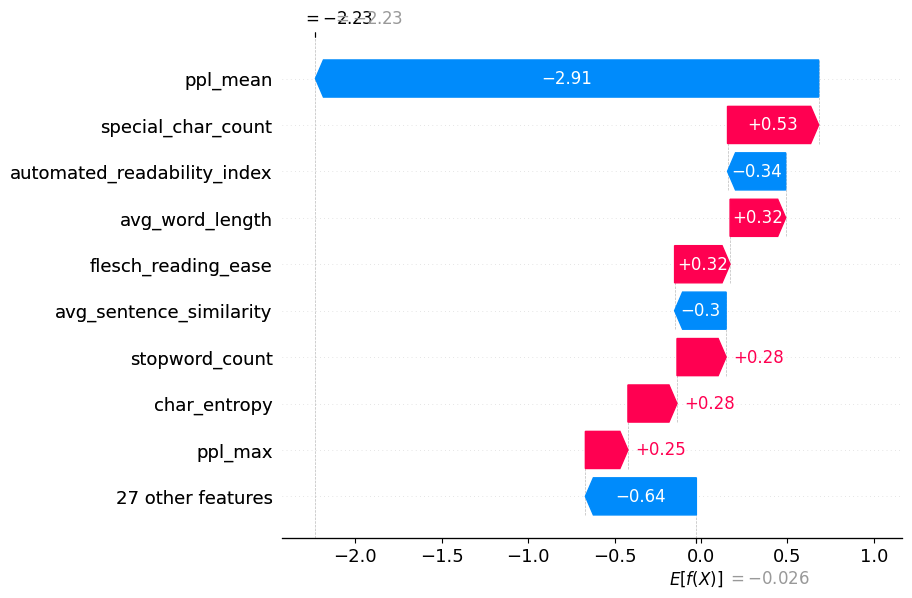

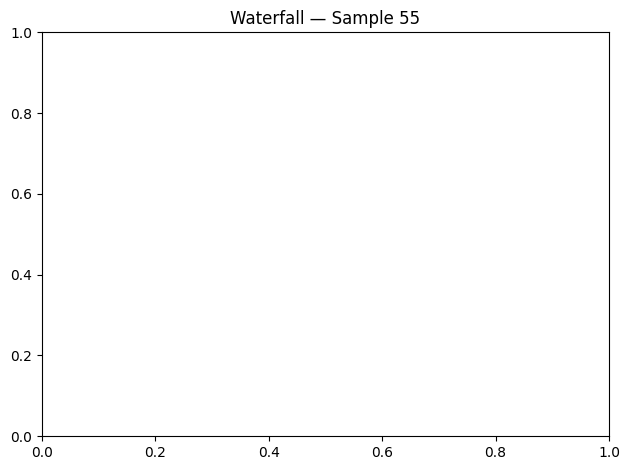

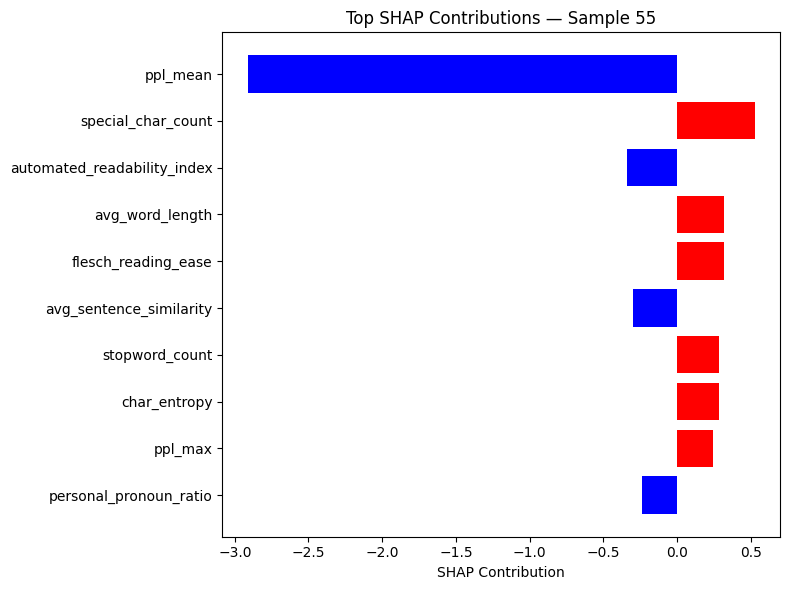


==================== TEXT SAMPLE ====================
Index: 4029
True Label: 0

TEXT:

Should remaining with the family be impossible, the same Act provides that any decision concerning children must contemplate providing them with continuous care and stable conditions of life corresponding to the children's needs and age and as nearly similar to those of a normal family environment as possible. ...



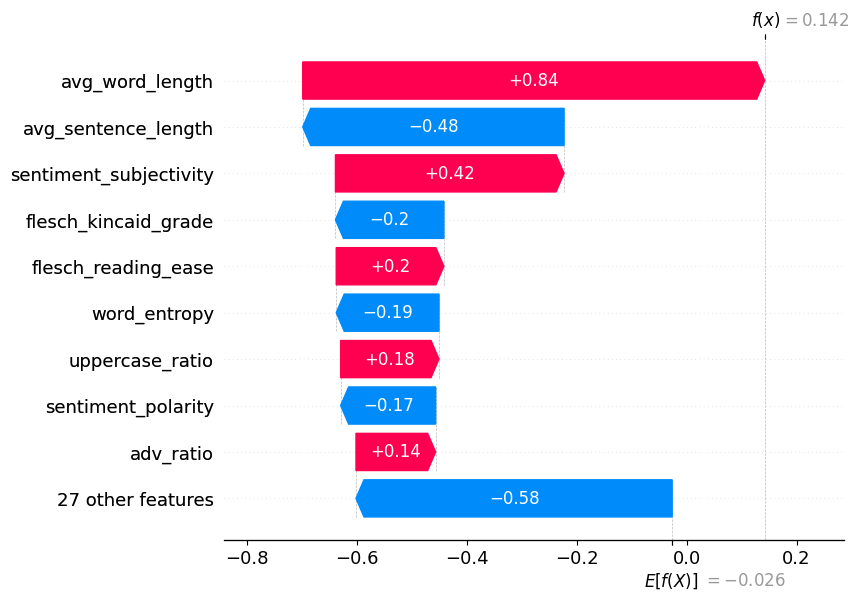

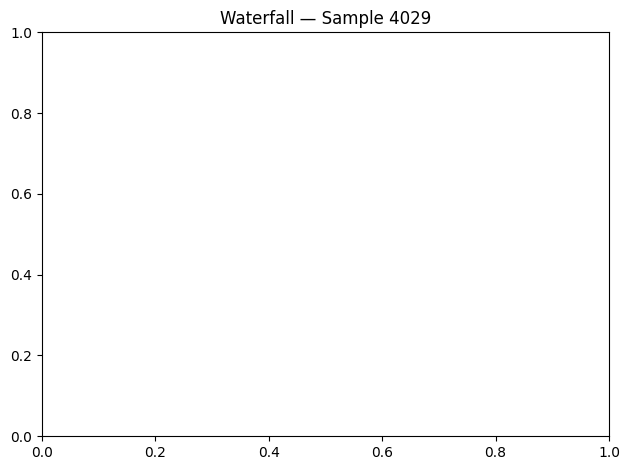

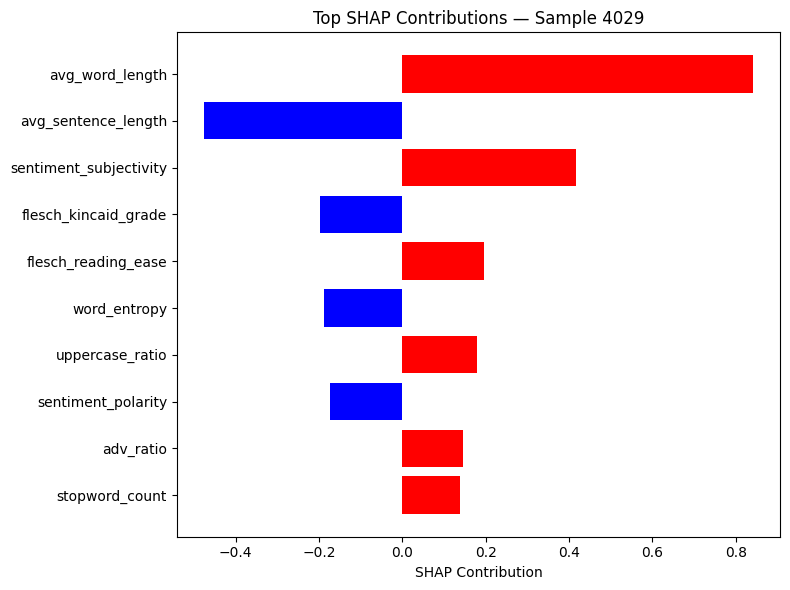


==================== TEXT SAMPLE ====================
Index: 8414
True Label: 1

TEXT:

Dear Principal, 

I am writing to respectfully argue against requiring students to have at least a B average in order to participate in sports and extracurricular activities. While good grades are important, imposing this grade restriction could negatively impact students in several ways.

First, disallowing participation for those with a C average may discourage students who are trying their best. For some students, sports or clubs are a motivating factor that encourages them to work hard in their classes too. Taking this away could lower morale and reduce academic motivation for borderline s ...



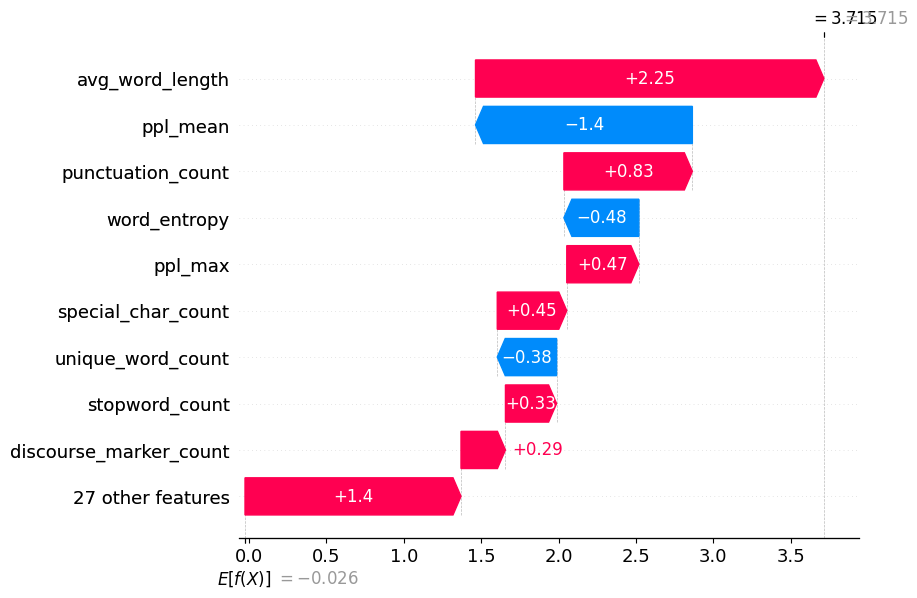

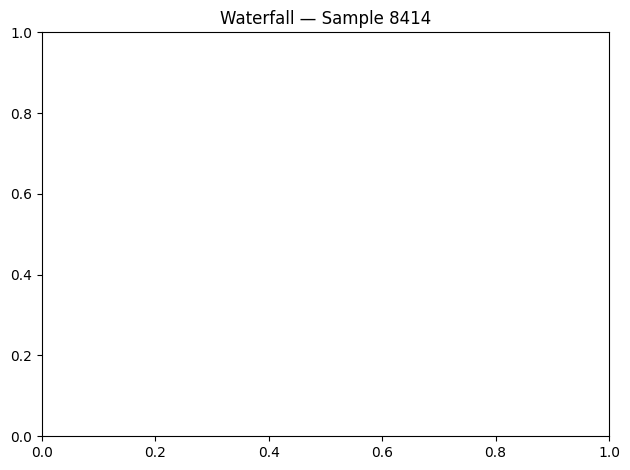

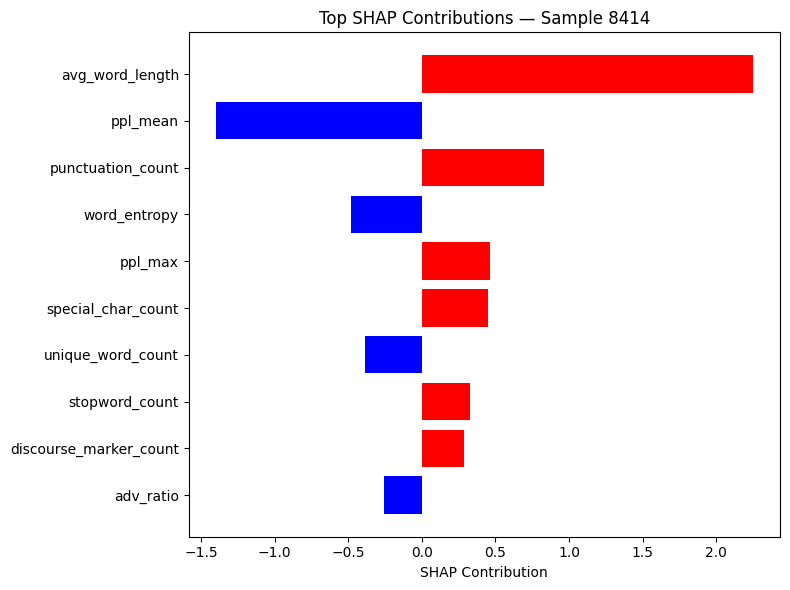


==================== TEXT SAMPLE ====================
Index: 3177
True Label: 0

TEXT:

How to find historical stock price for a de-listed or defunct company? ...



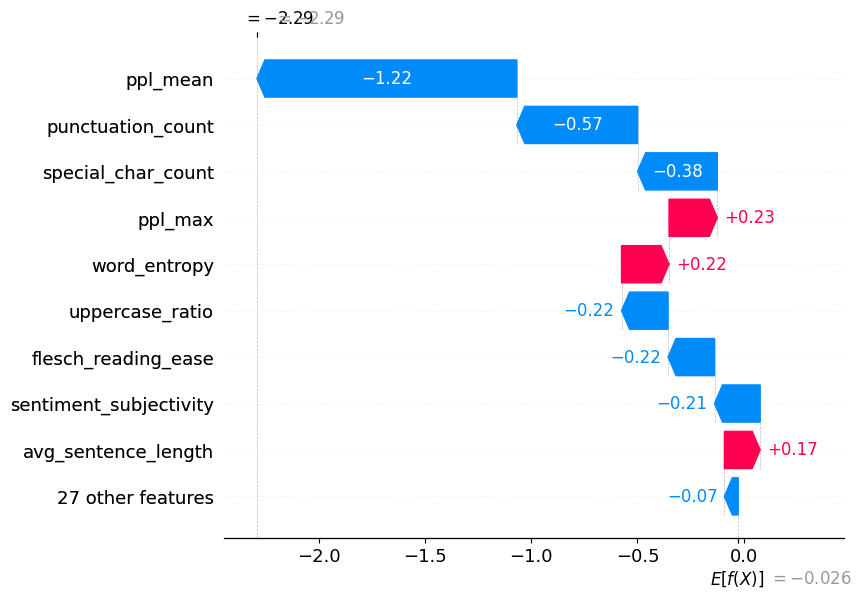

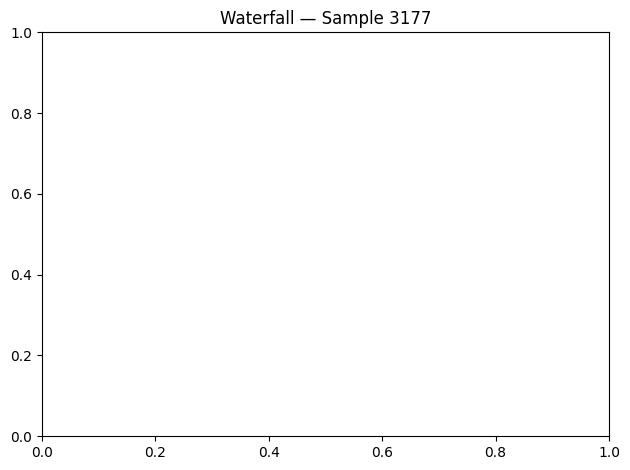

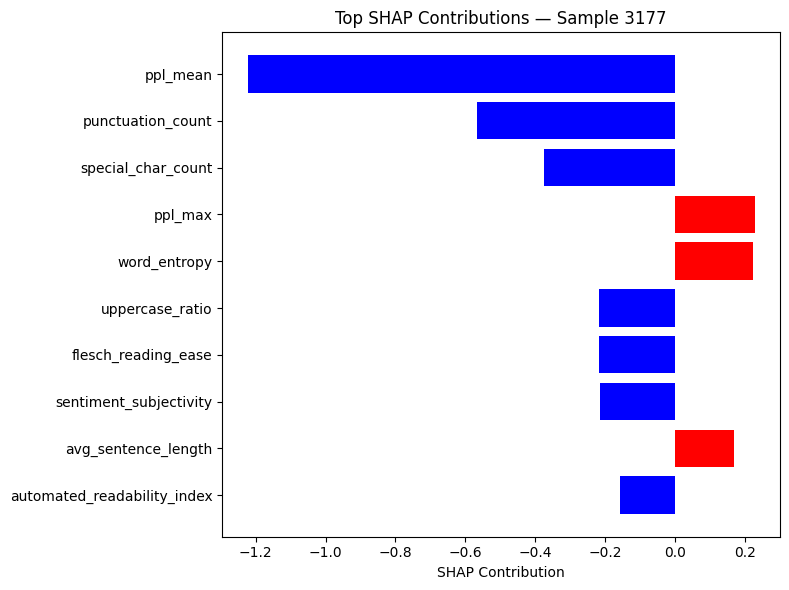


==================== SUMMARY TABLE CREATED ====================
   Index  True_Label  Predicted_Label  \
0   5911           1                1   
1   2919           0                0   
2   9785           1                1   
3     55           0                0   
4   4029           0                1   
5   8414           1                1   
6   3177           0                0   

                                        Top_Features  \
0  ppl_mean, punctuation_count, special_char_coun...   
1  ppl_mean, special_char_count, char_entropy, pp...   
2  ppl_mean, avg_sentence_similarity, avg_word_le...   
3  ppl_mean, special_char_count, automated_readab...   
4  avg_word_length, avg_sentence_length, sentimen...   
5  avg_word_length, ppl_mean, punctuation_count, ...   
6  ppl_mean, punctuation_count, special_char_coun...   

                          Contributions  \
0     2.658, 2.033, 0.827, 0.326, 0.304   
1  0.556, -0.539, -0.491, -0.445, 0.348   
2    2.567, 0.697, -0.497, 0

In [58]:
import shap

output_dir = r"C:\Users\ajha26\Desktop\IS\Results\SHAP_Examples"
os.makedirs(output_dir, exist_ok=True)


explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)
base_value = explainer_xgb.expected_value
feature_names = np.array(X.columns)


def print_text(idx):
    print("\n==================== TEXT SAMPLE ====================")
    print(f"Index: {idx}")
    print("True Label:", y_test.loc[idx])
    print("\nTEXT:\n")
    print(df.loc[idx, "Text"][:600], "...\n")


def plot_waterfall(shap_vals, title, idx, top_n=10):
    plt.figure(figsize=(9, 7))
    shap.plots._waterfall.waterfall_legacy(
        base_value,
        shap_vals,
        feature_names=feature_names,
        max_display=top_n
    )
    outpath = os.path.join(output_dir, f"{idx}_waterfall.png")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.show()
    return outpath


def plot_horizontal_bar(shap_vals, title, idx, n=10):
    idx_sorted = np.argsort(np.abs(shap_vals))[-n:][::-1]
    vals = shap_vals[idx_sorted]
    feats = feature_names[idx_sorted]
    colors = ["red" if v > 0 else "blue" for v in vals]

    plt.figure(figsize=(8, 6))
    plt.barh(feats, vals, color=colors)
    plt.title(title)
    plt.xlabel("SHAP Contribution")
    plt.gca().invert_yaxis()
    plt.tight_layout()

    outpath = os.path.join(output_dir, f"{idx}_bar.png")
    plt.savefig(outpath, dpi=200)
    plt.show()
    return outpath



def explain_samples(sample_indices, top_k_summary=5):
    rows = []

    for idx in sample_indices:
        print_text(idx)

        # --- SHAP values ---
        pos = X_test.index.get_loc(idx)
        shap_vals = shap_values_xgb[pos]
        sample = X_test.iloc[pos]

        # --- Predictions ---
        pred = best_xgb.predict(sample.values.reshape(1, -1))[0]

        # --- Plots ---
        wplot = plot_waterfall(shap_vals, 
                               f"Waterfall — Sample {idx}", 
                               idx)

        bplot = plot_horizontal_bar(shap_vals, 
                                    f"Top SHAP Contributions — Sample {idx}", 
                                    idx)

        # --- Top-K SHAP features summary ---
        order = np.argsort(np.abs(shap_vals))[-top_k_summary:][::-1]
        top_feats = feature_names[order]
        top_vals = shap_vals[order]

        rows.append({
            "Index": idx,
            "True_Label": int(y_test.loc[idx]),
            "Predicted_Label": int(pred),
            "Top_Features": ", ".join(top_feats),
            "Contributions": ", ".join([f"{v:.3f}" for v in top_vals]),
            "Waterfall_Plot": wplot,
            "Bar_Plot": bplot
        })

    return pd.DataFrame(rows)



ai_idx = y_test[y_test == 1].index[0]
human_idx = y_test[y_test == 0].index[0]

summary_df_2 = explain_samples([ai_idx, human_idx], top_k_summary=5)



np.random.seed(42)
random_indices = np.random.choice(list(X_test.index), size=5, replace=False)

summary_df_5 = explain_samples(random_indices, top_k_summary=5)


summary_final = pd.concat([summary_df_2, summary_df_5], ignore_index=True)

summary_path = os.path.join(output_dir, "SHAP_Summary_Table.csv")
summary_final.to_csv(summary_path, index=False)

print("\n==================== SUMMARY TABLE CREATED ====================")
print(summary_final)
print("\nSaved to:", summary_path)
